## Preliminary

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:\\FUFA Code\\Match-Analysis\\data\\processed\\FWSL_25_26_mid_season_matches_cleaned.csv')

## Professional FUFA Brand Chart Styling

All charts in this notebook have been enhanced with professional visualization design:

**Chart Design Principles Applied:**
- ✓ Creative styling: Narrower bars with white edges, hollow markers, gradient colors
- ✓ Professional typography: Bold titles only, regular weight for labels and ticks
- ✓ Color contrast: FUFA primaries (dark & light blue) highlighted, red for alerts
- ✓ Clean layouts: Removed unnecessary axes and visual clutter
- ✓ Data presentation: Horizontal bars for readability, annotations where they matter
- ✓ Subtle grids and reference lines that guide without distracting

**FUFA Brand Colors:**
- Dark Blue (#333d92) - Primary emphasis
- Light Blue (#007bc1) - Secondary accents  
- Red (#e00024) - Alert/low performance
- White/Gray - Clean backgrounds and gridlines

All charts are **report-ready** and visually compelling for stakeholder presentations!

In [3]:
#FUFA Brand Colours
mid_blue = '#353b91'
dark_blue = '#333d92'
white = '#ffffff'
light_blue = '#007bc1'
black = '#000000'
red = '#e00024'
yellow = '#f8f400'

# FUFA Brand Color Palette
FUFA_COLORS = {
    'primary_dark': dark_blue,
    'primary_mid': mid_blue,
    'primary_light': light_blue,
    'accent_red': red,
    'accent_yellow': yellow,
    'neutral_white': white,
    'neutral_black': black,
}

FUFA_CHART_PALETTE = [dark_blue, light_blue, '#5B7DA3', '#8FA3C1']

def apply_fufa_chart_theme(ax, remove_y_labels=False, remove_y_ticks=False, remove_x_labels=False):
    """Apply professional FUFA brand styling to chart axes with creative enhancements."""
    # Spine styling - minimal but present
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#D0D0D0')
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_color('#D0D0D0')
    ax.spines['bottom'].set_linewidth(0.8)
    
    # Grid - subtle, professional appearance
    ax.yaxis.grid(True, linestyle='-', alpha=0.15, color='#808080', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Axis management
    if remove_y_labels:
        ax.set_yticklabels([])
    if remove_y_ticks:
        ax.set_yticks([])
    if remove_x_labels:
        ax.set_xticklabels([])
    
    # Professional tick styling - not bold, just readable
    ax.tick_params(labelsize=8.5, colors='#404040')
    ax.xaxis.label.set_fontsize(9.5)
    ax.yaxis.label.set_fontsize(9.5)

def apply_professional_style(ax, title: str, xlabel: str = '', ylabel: str = ''):
    """Apply professional FUFA brand styling with creative enhancements."""
    apply_fufa_chart_theme(ax)
    
    # Title - bold and prominent
    ax.set_title(title, fontsize=13, fontweight='bold', pad=18, color=dark_blue)
    
    # Axis labels - regular weight, darker color for contrast
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9.5, fontweight='400', color='#1F1F1F')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=9.5, fontweight='400', color='#1F1F1F')
    
    # Tick styling
    ax.tick_params(axis='x', labelsize=8.5, colors='#404040')
    ax.tick_params(axis='y', labelsize=8.5, colors='#404040')

In [4]:
df.shape

(571, 89)

In [5]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns#all numeric columns
num_cols = ['duration','distance_km','sprint_distance_m','power_plays','energy_kcal','impacts',
                   'player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']# numeric columns of high interest
intensity_metrics =['player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']
volume_metrics = ['distance_km','sprint_distance_m','power_plays','energy_kcal','impacts']


In [6]:
df['match_day'] = df['match_day'].str.replace('Wmd', 'MD')

In [7]:
from IPython.display import HTML

def style_table_for_docs(df, hide_index=False):
    styled = (
        df.style
        .set_properties(**{
            'color': 'black',
            'background-color': 'white',
            'border': '1px solid black',
            'text-align': 'center',
            'padding': '2px'  # reduces row height
        })
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')  # also reduce header row height
            ]},
            {'selector': 'td', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')
            ]},
            {'selector': 'table', 'props': [
                ('border', '2px solid black'), 
                ('border-collapse', 'collapse')
            ]}
        ])
    )
    
    if hide_index:
        styled = styled.hide(axis='index')

    return styled


In [8]:
df['total_accelerations'] = df[
	[
		'accelerations_zone_count:_1__2_mss',
		'accelerations_zone_count:_2__3_mss',
		'accelerations_zone_count:_3__4_mss',
		'accelerations_zone_count:_>_4_mss'
	]
].sum(axis=1)

df['total_decelerations'] = df[
	[
		'deceleration_zone_count:_1__2_mss',
		'deceleration_zone_count:_2__3_mss',
		'deceleration_zone_count:_3__4_mss',
		'deceleration_zone_count:_>_4_mss'
	]
].sum(axis=1)


In [9]:
volume_metrics.append('total_accelerations')
volume_metrics.append('total_decelerations')

df['acc_counts_per_min'] = df['total_accelerations'] / df['duration']
df['dec_counts_per_min'] = df['total_decelerations'] / df['duration']

intensity_metrics.append('acc_counts_per_min')
intensity_metrics.append('dec_counts_per_min')

In [10]:
df['p_name'].nunique()

105

## Summary

In [11]:
table1 = df[['player_load','power_score_wkg','work_ratio']].agg(['sum', 'mean', 'std']).T
style_table_for_docs(table1.round(2))

,sum,mean,std
player_load,234395.600000,410.500000,66.160000
power_score_wkg,2149.130000,3.760000,0.840000
work_ratio,11013.810000,19.290000,5.210000


In [12]:
summary_table_intensity = df[intensity_metrics].agg(['max', 'mean', 'std']).T
style_table_for_docs(summary_table_intensity.round(2))

,max,mean,std
player_load,633.770000,410.500000,66.160000
top_speed_kmh,32.350000,25.980000,2.070000
distance_per_min_mmin,116.750000,85.890000,13.540000
power_score_wkg,6.680000,3.760000,0.840000
work_ratio,39.560000,19.290000,5.210000
max_acceleration_mss,9.810000,5.330000,0.560000
max_deceleration_mss,10.000000,6.590000,0.920000
acc_counts_per_min,6.970000,4.140000,0.790000
dec_counts_per_min,6.850000,4.030000,0.780000


In [13]:
summary_table_volume = df[volume_metrics].agg(['sum','mean', 'std']).T
style_table_for_docs(summary_table_volume.round(2))

,sum,mean,std
distance_km,4788.080000,8.390000,1.290000
sprint_distance_m,283461.810000,496.430000,228.760000
power_plays,25052.000000,43.870000,14.350000
energy_kcal,477933.350000,837.010000,158.970000
impacts,3658.000000,6.410000,6.420000
total_accelerations,230687.000000,404.010000,76.280000
total_decelerations,224598.000000,393.340000,75.050000


## Data Overview

In [14]:
unique_players_per_club = df.groupby('club_for')['p_name'].nunique().reset_index()
unique_players_per_club.columns = ['club_for', 'unique_players']
style_table_for_docs(unique_players_per_club.sort_values(by='unique_players', ascending=False))

,club_for,unique_players
5,She Maroons Fc,19
3,Lady Doves Fc,17
4,Makerere University Wfc,17
0,Amus College Wfc,16
1,Kampala Queens Fc,14
6,Uganda Martyrs Hs Wfc,12
2,Kawempe Muslim Lfc,11


In [15]:
players_match_days = df.groupby(['p_name', 'player_club_'])['match_day'].nunique().reset_index()
players_match_days.columns = ['p_name', 'player_club_', 'unique_match_days']
style_table_for_docs(players_match_days.sort_values(by='unique_match_days', ascending=False).head(10))

,p_name,player_club_,unique_match_days
1,Agnes Nabukenya,Kawempe Muslim Lfc,11
8,Asia Nakibuuka,Kawempe Muslim Lfc,11
6,Amina Nakato,Kawempe Muslim Lfc,11
34,Hadijah Babirye,Kawempe Muslim Lfc,11
71,Nagadya Catherine,Kampala Queens Fc,11
69,Nabulime Jamilah,Kampala Queens Fc,11
53,Kauthra Naluyima,She Maroons Fc,11
55,Krusum Namutebi,Kawempe Muslim Lfc,11
56,Latifah Nakasi,Kawempe Muslim Lfc,11
45,Jovia Nakagolo,Kawempe Muslim Lfc,11


In [16]:
# Calculate average number of unique players per matchday for each club
players_per_club_day = df.groupby(['club_for', 'match_day'])['p_name'].nunique().reset_index()
avg_players_per_matchday = players_per_club_day.groupby('club_for')['p_name'].mean().reset_index()
avg_players_per_matchday.columns = ['club_for', 'avg_players_per_matchday']
style_table_for_docs(avg_players_per_matchday.sort_values(by='avg_players_per_matchday', ascending=False))

,club_for,avg_players_per_matchday
5,She Maroons Fc,10.272727
2,Kawempe Muslim Lfc,10.000000
0,Amus College Wfc,9.000000
4,Makerere University Wfc,9.000000
6,Uganda Martyrs Hs Wfc,8.750000
1,Kampala Queens Fc,8.454545
3,Lady Doves Fc,6.111111


In [17]:
# Count the number of unique matchdays for each club
unique_matchdays_per_club = df.groupby('club_for')['match_day'].nunique().reset_index()
unique_matchdays_per_club.columns = ['club_for', 'unique_matchdays']
style_table_for_docs(unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False))

,club_for,unique_matchdays
1,Kampala Queens Fc,11
2,Kawempe Muslim Lfc,11
5,She Maroons Fc,11
4,Makerere University Wfc,10
3,Lady Doves Fc,9
0,Amus College Wfc,6
6,Uganda Martyrs Hs Wfc,4


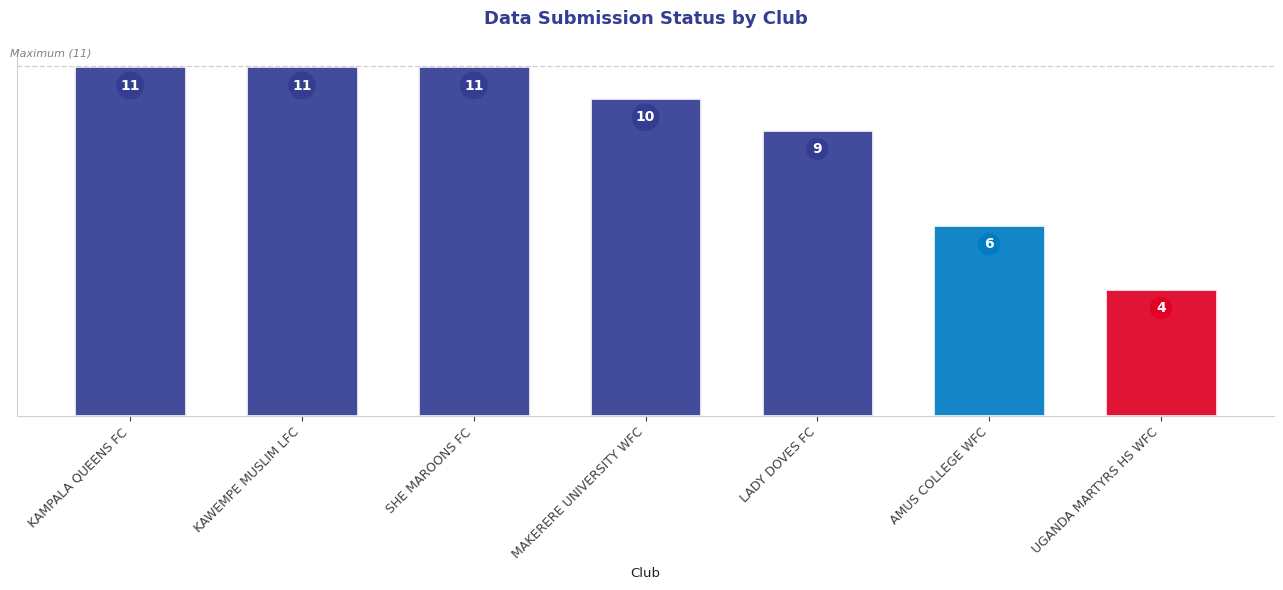

In [18]:
# Sort data
data = unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False)

# Define usage tiers and corresponding FUFA brand colors
def usage_tier_color(val):
    if val >= 8:
        return dark_blue  # FUFA primary dark blue for high engagement
    elif val >= 5:
        return light_blue  # FUFA light blue for medium
    else:
        return red  # FUFA red for low

colors = data['unique_matchdays'].map(usage_tier_color).tolist()

# Create professional barplot with creative styling
fig, ax = plt.subplots(figsize=(13, 6), facecolor='white')

# Narrower bars with white edges for professional appearance
bars = ax.bar(
    range(len(data)), data['unique_matchdays'],
    color=colors, edgecolor='white', linewidth=2, alpha=0.92, width=0.65
)

# Benchmark line - subtle reference
ax.axhline(11, color='#A9A9A9', linestyle='--', linewidth=1, alpha=0.5)
ax.text(-0.7, 11.3, 'Maximum (11)', color='#808080', fontsize=8, style='italic', fontweight='400')

# Professional axis styling
apply_professional_style(ax, 'Data Submission Status by Club', 'Club', '')
ax.set_xticks(range(len(data)))
ax.set_xticklabels([name.upper() for name in data['club_for']], rotation=45, ha='right', fontsize=9, fontweight='400')

# Remove y-axis for cleaner look
ax.set_yticks([])
ax.set_yticklabels([])

# Annotate values with professional styling
for i, value in enumerate(data['unique_matchdays']):
    ax.text(
        i, value - 0.6, str(int(value)),
        ha='center', va='center',
        fontsize=10, color='white', fontweight='600',
        bbox=dict(boxstyle='circle,pad=0.3', edgecolor='none', facecolor=colors[i], alpha=0.95)
    )

plt.tight_layout()
plt.show()

In [19]:
# uploaded_matches = {
#     "She Maroons FC": 20,
#     "Kawempe Muslim LFC": 22,
#     "Uganda Martyrs Lubaga WFC": 18,
#     "Rines SS WFC": 22,
#     "Amus College WFC": 19,
#     "Wakiso Hill WFC": 18,
#     "Lady Doves FC": 16,
#     "Makerere University WFC": 22,
#     "Kampala Queens FC": 17,
#     "Olila HS WFC": 13,
#     "She Corporates FC": 5,
#     "FC Tooro Queens": 0,
    
# }

# uploaded_matches_df = pd.DataFrame(uploaded_matches.items(), columns=['club_for', 'uploaded_matches'])
# uploaded_matches_df['club_for'] = uploaded_matches_df['club_for'].str.title()

# uploaded_matches_df=uploaded_matches_df.merge(unique_matchdays_per_club, on='club_for', how='left').sort_values(by='unique_matchdays', ascending=False)
# uploaded_matches_df = uploaded_matches_df.rename(columns={
#     'uploaded_matches': 'Uploaded Matchdays',
#     'unique_matchdays': 'Analysed Matchdays',
# })

In [20]:

# # Prepare DataFrame
# uploaded_matches_df_copy = uploaded_matches_df.copy()
# uploaded_matches_df_copy['Analysed']      = uploaded_matches_df_copy['Analysed Matchdays']
# uploaded_matches_df_copy['Pending']       = uploaded_matches_df_copy['Uploaded Matchdays'] - uploaded_matches_df_copy['Analysed Matchdays']
# uploaded_matches_df_copy['not_uploaded']  = 22 - uploaded_matches_df_copy['Uploaded Matchdays']
# uploaded_matches_df_copy = uploaded_matches_df_copy.sort_values('Analysed Matchdays', ascending=False)

# # Lighter color palette
# colors = {
#     'Analysed':      "#38759e",  # softer blue
#     'Pending':       "#ee9d50",  # softer orange
#     'not_uploaded':  "#f8373a"   # softer red
# }

# fig, ax = plt.subplots(figsize=(12,6))
# x = np.arange(len(uploaded_matches_df_copy))

# # Plot segments
# ax.bar(x, uploaded_matches_df_copy['Analysed'],
#        color=colors['Analysed'],
#        label='Analysed')
# ax.bar(x, uploaded_matches_df_copy['Pending'],
#        bottom=uploaded_matches_df_copy['Analysed'],
#        color=colors['Pending'],
#        label='Uploaded – Not Analysed')
# ax.bar(x, uploaded_matches_df_copy['not_uploaded'],
#        bottom=uploaded_matches_df_copy['Analysed'] + uploaded_matches_df_copy['Pending'],
#        color=colors['not_uploaded'],
#        label='Not Uploaded')

# # Benchmark line
# ax.axhline(22, color='gray', linestyle='--', linewidth=1)
# ax.text(-0.5, 22.5, 'MAXIMUM (22)', color='gray', fontsize=9)

# # X labels
# ax.set_xticks(x)
# ax.set_xticklabels(uploaded_matches_df_copy['club_for'].str.upper(), rotation=90, fontsize=9)

# # Clean Y axis
# ax.set_yticks([])
# ax.set_ylabel('')

# # Titles
# ax.set_xlabel('CLUB', fontsize=11)
# ax.set_title('MATCHDAY COVERAGE PER CLUB', fontsize=14, fontweight='bold',pad='30')

# # Gridlines
# ax.yaxis.grid(True, linestyle='--', alpha=0.5)
# ax.set_axisbelow(True)

# # Remove spines
# sns.despine(ax=ax, left=True, top=True, right=True)

# # Annotation helper
# def draw_circle_text(xpos, ypos, txt, color):
#     ax.text(
#         xpos, ypos, str(int(txt)),
#         ha='center', va='center', color='black',
#         fontsize=8, fontweight='bold',
#         bbox=dict(boxstyle="circle,pad=0.3", facecolor='white', edgecolor='none')
#     )

# # Annotate segments
# for idx, row in enumerate(uploaded_matches_df_copy.itertuples()):
#     analysed = row.Analysed
#     pending  = row.Pending
#     notup    = row.not_uploaded

#     # Analysed (always)
#     if analysed > 0:
#         draw_circle_text(idx, analysed / 2, analysed, colors['Analysed'])

#     # Pending (always)
#     if pending > 1:
#         draw_circle_text(idx, analysed + pending / 2, pending, colors['Pending'])

#     # not_uploaded (only if > 1)
#     if notup > 1:
#         ypos = analysed + pending + notup / 2
#         draw_circle_text(idx, ypos, notup, colors['not_uploaded'])

# # Legend outside
# ax.legend(
#     loc='upper left',
#     bbox_to_anchor=(1.02, 1),
#     borderaxespad=0,
#     frameon=False
# )

# plt.tight_layout()
# plt.show()


In [21]:
# import matplotlib.patches as mpatches

# # 1. Get sorted lists of clubs & matchdays
# clubs = sorted(df['club_for'].unique())

# # Sort matchdays in correct order: MD1, MD2, ..., MD22
# matchday_order = [f'MD{i}' for i in range(1, 23)]
# matchdays = [md for md in matchday_order if md in df['match_day'].unique()]

# # 2. Build a binary grid (1 = analysed, 0 = missing)
# grid_data = []
# for md in matchdays:
#     row = []
#     for club in clubs:
#         mask = (df['match_day'] == md) & (df['club_for'] == club)
#         is_present = 1 if df.loc[mask, 'p_name'].nunique() > 0 else 0
#         row.append(is_present)
#     grid_data.append(row)

# # 3. Convert to DataFrame
# grid_df = pd.DataFrame(grid_data, index=matchdays, columns=clubs)

# # 4. Define colors
# color_map = {1: '#5cb85c', 0: '#d9534f'}  # green = uploaded, red = missing

# # 5. Plot
# fig, ax = plt.subplots(figsize=(len(clubs)*0.6 + 2, len(matchdays)*0.4 + 2))

# for y, md in enumerate(matchdays):
#     for x, club in enumerate(clubs):
#         val = grid_df.loc[md, club]
#         color = color_map[val]
#         rect = plt.Rectangle((x, y), 1, 1, facecolor=color, edgecolor='white')
#         ax.add_patch(rect)

# # 6. Axis Labels
# ax.set_xticks(np.arange(len(clubs)) + 0.5)
# ax.set_xticklabels([c.upper() for c in clubs], rotation=90, fontsize=9)
# ax.set_yticks(np.arange(len(matchdays)) + 0.5)
# ax.set_yticklabels([i.upper() for i in matchdays], fontsize=9)

# ax.set_xlim(0, len(clubs))
# ax.set_ylim(0, len(matchdays))
# ax.invert_yaxis()

# ax.set_xlabel('Club', fontsize=11)
# ax.set_ylabel('Match Day', fontsize=11)
# ax.set_title('Matchdays Analysed per Club', fontsize=13, fontweight='bold')

# # 7. Legend
# handles = [
#     mpatches.Patch(color=color_map[1], label='Analysed Matchday'),
#     mpatches.Patch(color=color_map[0], label='Missing Matchday')
# ]
# ax.legend(handles=handles, title='Color Map', loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)

# plt.tight_layout()
# plt.show()


In [22]:
# Calculate total player entries per matchday across all clubs
total_players_per_matchday = df.groupby('match_day')['p_name'].count().reset_index()
total_players_per_matchday.columns = ['match_day', 'total_player_entries']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'Md{i}' for i in range(1, 12)]
total_players_per_matchday['match_day'] = pd.Categorical(
    total_players_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(total_players_per_matchday.sort_values(by='match_day'))

,match_day,total_player_entries
0,Md1,52
3,Md2,54
4,Md3,45
5,Md4,63
6,Md5,54
7,Md6,51
8,Md7,61
9,Md8,54
10,Md9,54
1,Md10,47


In [23]:
# Count the number of unique clubs that submitted data per matchday
clubs_per_matchday = df.groupby('match_day')['club_for'].nunique().reset_index()
clubs_per_matchday.columns = ['match_day', 'num_clubs']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'Md{i}' for i in range(1, 12)]
clubs_per_matchday['match_day'] = pd.Categorical(
    clubs_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(clubs_per_matchday.sort_values(by='match_day'))


,match_day,num_clubs
0,Md1,6
3,Md2,6
4,Md3,5
5,Md4,5
6,Md5,6
7,Md6,6
8,Md7,7
9,Md8,6
10,Md9,6
1,Md10,5


In [24]:
def plot_line_with_values(data, x_col, y_col, title=None, x_label=None, y_label=None, figsize=(11, 5.5), line_color=None):
    """Create a professional FUFA-branded line chart with value annotations."""
    
    if line_color is None:
        line_color = dark_blue
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    
    # Sort data if match_day
    if x_col == 'match_day':
        data = data.copy()
        data[x_col] = pd.Categorical(data[x_col], categories=matchday_order, ordered=True)
        data = data.sort_values(by=x_col)
    
    # Plot the line with professional styling
    ax.plot(range(len(data)), data[y_col].values, marker='o', color=line_color, linewidth=2.5, 
            markersize=7, markerfacecolor='white', markeredgecolor=line_color, markeredgewidth=2.5)
    
    # Apply FUFA theme
    apply_fufa_chart_theme(ax, remove_y_labels=False)
    
    # Set x-axis labels
    if x_col == 'match_day':
        xticklabels = [str(md).replace('Md', 'MD') for md in data[x_col]]
        ax.set_xticks(range(len(data)))
        ax.set_xticklabels(xticklabels, rotation=0, fontsize=9)
    
    # Add value labels above each point with professional styling
    for i, (x, y) in enumerate(zip(range(len(data)), data[y_col])):
        ax.annotate(
            f'{int(y) if y == int(y) else y:.1f}', 
            (x, y),
            textcoords='offset points', 
            xytext=(0, 10), 
            ha='center',
            fontsize=8,
            color='black',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', edgecolor=light_blue, facecolor='white', linewidth=1.2, alpha=0.95)
        )
    
    # Titles and labels
    if title is None:
        title = f'{y_col.replace("_", " ").title()} vs {x_col.replace("_", " ").title()}'
    ax.set_title(title, fontsize=12, fontweight='700', pad=15)
    
    if x_label is None:
        x_label = x_col.replace('_', ' ').title()
    ax.set_xlabel(x_label, fontsize=10, fontweight='600')
    
    if y_label is None:
        y_label = y_col.replace('_', ' ').title()
    ax.set_ylabel(y_label, fontsize=10, fontweight='600')
    
    plt.tight_layout()
    return ax


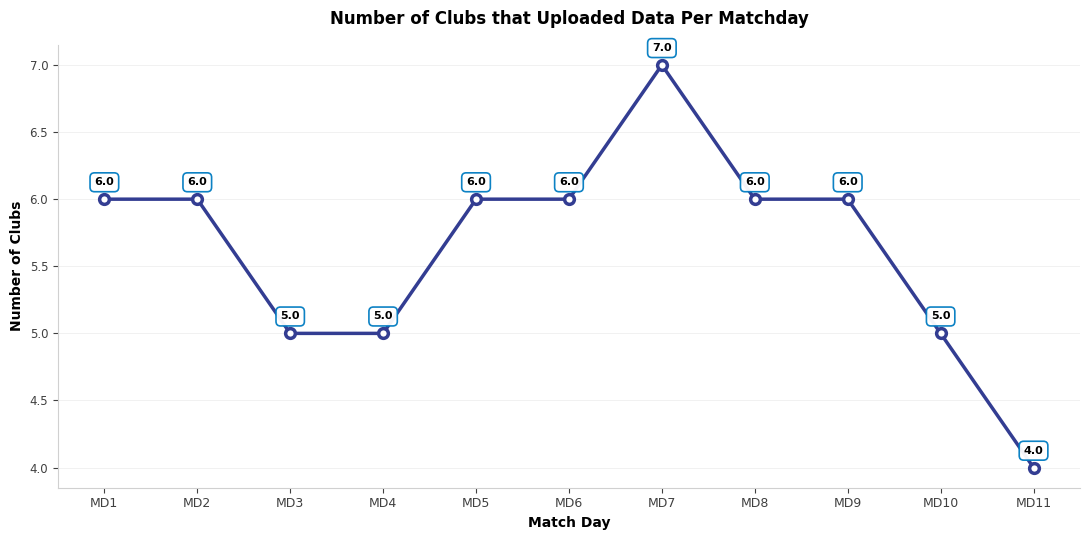

In [25]:
plot_line_with_values(clubs_per_matchday, 'match_day', 'num_clubs', title='Number of Clubs that Uploaded Data Per Matchday',x_label='Match Day', y_label='Number of Clubs');

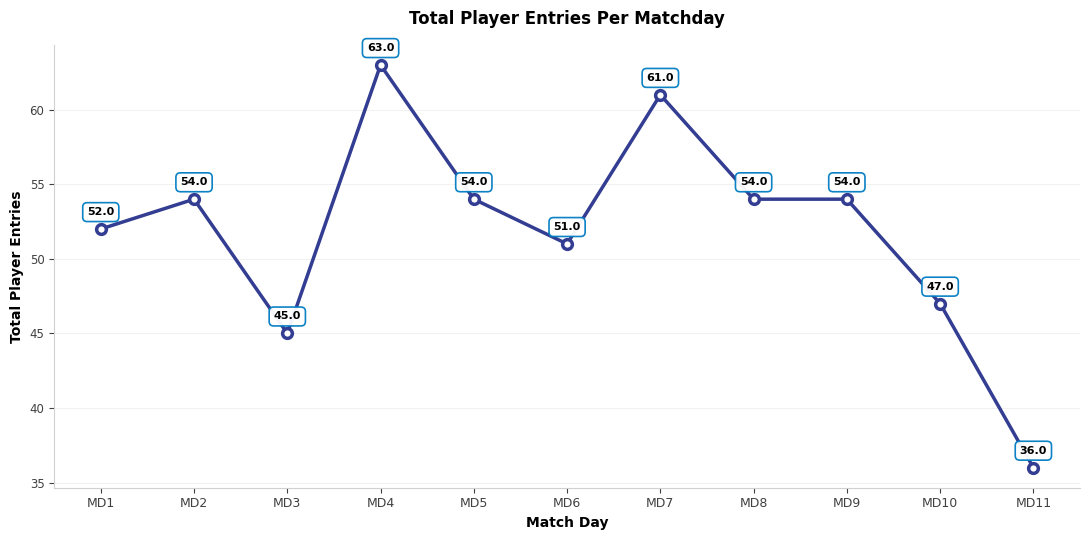

In [26]:
plot_line_with_values(total_players_per_matchday, 'match_day', 'total_player_entries', title='Total Player Entries Per Matchday', x_label='Match Day', y_label='Total Player Entries');

In [27]:
# Count number and percentage of entries based on 'location'
location_counts = df['location'].value_counts().reset_index()
location_counts.columns = ['location', 'count']
location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

style_table_for_docs(location_counts)

,location,count,percentage
0,Home,290,50.788091
1,Away,281,49.211909


In [28]:
# Count number and percentage of entries based on 'result'
location_counts = df['result'].value_counts().reset_index()
location_counts.columns = ['result', 'count']
location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

style_table_for_docs(location_counts)

,result,count,percentage
0,Win,256,44.833625
1,Draw,173,30.297723
2,Loss,142,24.868651


In [29]:
# Calculate Win-Draw-Loss counts for each club using unique match days
matchday_results = df.groupby(['club_for', 'match_day'])['result'].first().reset_index()
wld_counts = matchday_results.groupby(['club_for', 'result']).size().unstack(fill_value=0)
wld_counts = wld_counts[['Win', 'Draw', 'Loss']]  # Ensure order if all present

style_table_for_docs(wld_counts.sort_values(by='Win', ascending=False))


result,Win,Draw,Loss
club_for,,,
Kawempe Muslim Lfc,9,1,1
Kampala Queens Fc,6,3,2
She Maroons Fc,4,3,4
Amus College Wfc,3,2,1
Lady Doves Fc,2,4,3
Makerere University Wfc,2,4,4
Uganda Martyrs Hs Wfc,2,1,1


### Max Metrics

In [30]:
speed_table = df[['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']].agg(['max', 'mean', 'std']).T
style_table_for_docs(speed_table)

,max,mean,std
top_speed_kmh,32.352120,25.975354,2.074598
distance_per_min_mmin,116.753649,85.890037,13.544859
max_acceleration_mss,9.811200,5.325497,0.557703
max_deceleration_mss,10.000000,6.588264,0.924445


In [31]:
distance_speed_zones = ['distance_in_speed_zone_1_km', 'distance_in_speed_zone_2_km', 'distance_in_speed_zone_3_km','distance_in_speed_zone_4_km','distance_in_speed_zone_5_km']
for i in distance_speed_zones:
    df[i] = df[i] * 1000  # Convert from km to m

speed_zone_dist= df[distance_speed_zones].agg(['sum','max', 'mean', 'std']).T.round(2)
style_table_for_docs(speed_zone_dist)

,sum,max,mean,std
distance_in_speed_zone_1_km,581330.000000,4261.400000,1018.090000,385.510000
distance_in_speed_zone_2_km,2547113.200000,6159.600000,4460.790000,700.490000
distance_in_speed_zone_3_km,1376172.900000,4701.800000,2410.110000,756.770000
distance_in_speed_zone_4_km,266988.900000,1221.900000,467.580000,201.970000
distance_in_speed_zone_5_km,16471.500000,210.800000,28.850000,39.860000


## Analysis

### Club Comparison

In [32]:
club_metrics_mean = (
    df.groupby(['club_for', 'match_day'],observed=False)[volume_metrics+intensity_metrics].mean()
    .groupby('club_for').mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_distance_km', ascending=False)
    .reset_index()
)
style_table_for_docs(club_metrics_mean.round(2).T)


,0,1,2,3,4,5,6
club_for,Lady Doves Fc,Kampala Queens Fc,She Maroons Fc,Makerere University Wfc,Kawempe Muslim Lfc,Amus College Wfc,Uganda Martyrs Hs Wfc
avg_distance_km,8.530000,8.380000,8.370000,8.360000,8.300000,8.210000,7.890000
avg_sprint_distance_m,488.030000,508.130000,534.600000,456.800000,499.830000,492.640000,446.440000
avg_power_plays,42.600000,44.030000,46.030000,40.940000,45.260000,43.650000,38.750000
avg_energy_kcal,784.960000,818.700000,946.960000,767.690000,846.350000,802.290000,764.890000
avg_impacts,6.370000,6.910000,5.310000,7.730000,4.980000,5.210000,10.050000
avg_total_accelerations,399.430000,427.180000,394.540000,403.740000,402.360000,384.930000,381.600000
avg_total_decelerations,387.380000,410.930000,385.140000,394.080000,391.070000,378.030000,378.190000
avg_player_load,417.520000,426.680000,403.280000,412.810000,396.690000,392.840000,395.910000
avg_top_speed_kmh,26.220000,26.840000,26.050000,25.380000,25.870000,26.010000,25.640000


In [33]:
team_avg_dist_per_match = (
    df
    .groupby(['club_for', 'match_day'], observed=False)['distance_km']
    .sum()  # Total team distance on a match day
    .groupby('club_for')
    .mean()  # Average total team distance per match across all match days
    .reset_index(name='avg_team_distance_per_match_km')
    .sort_values(by='avg_team_distance_per_match_km', ascending=False)
)
style_table_for_docs(team_avg_dist_per_match)

,club_for,avg_team_distance_per_match_km
5,She Maroons Fc,85.853373
2,Kawempe Muslim Lfc,82.984764
4,Makerere University Wfc,75.343870
3,Lady Doves Fc,75.012522
0,Amus College Wfc,74.034850
1,Kampala Queens Fc,70.786927
6,Uganda Martyrs Hs Wfc,69.861200


In [34]:
club_intensity_max = (
    df.groupby('club_for')[['top_speed_kmh', 'distance_per_min_mmin']]
    .max()
    .rename(columns=lambda x: f'max_{x}')
    .sort_values(by='max_top_speed_kmh', ascending=False)
    .reset_index()
)
style_table_for_docs(club_intensity_max.round(2))

,club_for,max_top_speed_kmh,max_distance_per_min_mmin
0,Kawempe Muslim Lfc,32.350000,106.490000
1,Kampala Queens Fc,31.930000,110.700000
2,She Maroons Fc,30.800000,111.640000
3,Makerere University Wfc,29.960000,111.560000
4,Uganda Martyrs Hs Wfc,29.780000,104.790000
5,Amus College Wfc,29.760000,103.870000
6,Lady Doves Fc,29.490000,116.750000


In [35]:
club_intensity_avg = (
    df.groupby('club_for')[['top_speed_kmh', 'distance_per_min_mmin']]
    .mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_top_speed_kmh', ascending=False)
    .reset_index()
)
style_table_for_docs(club_intensity_avg.round(2))

,club_for,avg_top_speed_kmh,avg_distance_per_min_mmin
0,Kampala Queens Fc,26.860000,87.250000
1,Amus College Wfc,26.050000,80.700000
2,She Maroons Fc,26.020000,86.720000
3,Kawempe Muslim Lfc,25.870000,88.440000
4,Uganda Martyrs Hs Wfc,25.800000,76.790000
5,Lady Doves Fc,25.740000,90.780000
6,Makerere University Wfc,25.360000,82.850000


### Metric High Scores

In [36]:
# For each metric, find the player with the highest value, the value, and the club
top_players = []
for metric in volume_metrics +intensity_metrics:
    idx = df[metric].idxmax()
    row = df.loc[idx]
    top_players.append({
        'metric': metric,
        'player': row['p_name'],
        'club': row['club_for'],
        'value': row[metric],
        'match day': row['match_day']
    })

top_players_df = pd.DataFrame(top_players)
style_table_for_docs(top_players_df)

,metric,player,club,value,match day
0,distance_km,Faith Apio,She Maroons Fc,11.277600,Md10
1,sprint_distance_m,Doreen Monica Nakayiwa,She Maroons Fc,1418.194000,Md8
2,power_plays,Doreen Monica Nakayiwa,She Maroons Fc,85.000000,Md7
3,energy_kcal,Faith Apio,She Maroons Fc,1324.454000,Md10
4,impacts,Moureen Kiiza,Uganda Martyrs Hs Wfc,87.000000,Md9
5,total_accelerations,Namusoke Esther,Kampala Queens Fc,679.000000,Md5
6,total_decelerations,Moureen Kiiza,Uganda Martyrs Hs Wfc,714.000000,Md7
7,player_load,Namusoke Esther,Kampala Queens Fc,633.769000,Md5
8,top_speed_kmh,Jovia Nakagolo,Kawempe Muslim Lfc,32.352120,Md9
9,distance_per_min_mmin,Lydia Nyandera,Lady Doves Fc,116.753649,Md4


In [37]:
# Filter players who played all 11 match days
players_all_matchdays = df.groupby('p_name')['match_day'].nunique()
players_all_matchdays = players_all_matchdays[players_all_matchdays == 11].index.tolist()

# Get data for these players
df_all_matchdays = df[df['p_name'].isin(players_all_matchdays)]

# Calculate average metrics for these players
all_matchdays_stats = (
    df_all_matchdays.groupby(['p_name', 'general_position','player_position', 'club_for'])[
        ['distance_km', 'player_load', 'sprint_distance_m', 'top_speed_kmh']
    ].mean()
    .reset_index()
    .sort_values(by='distance_km', ascending=False)
    .round(2)
)

style_table_for_docs(all_matchdays_stats)

,p_name,general_position,player_position,club_for,distance_km,player_load,sprint_distance_m,top_speed_kmh
0,Agnes Nabukenya,Midfielders,Am,Kawempe Muslim Lfc,9.260000,448.040000,482.840000,25.630000
8,Latifah Nakasi,Forwards,Fw,Uganda Martyrs Hs Wfc,9.180000,432.210000,359.580000,25.090000
9,Lilian Veronicah Masinde,Defenders,Df,She Maroons Fc,9.080000,430.880000,737.960000,26.670000
4,Jovia Nakagolo,Forwards,Fwd,Kawempe Muslim Lfc,8.640000,393.300000,993.290000,30.100000
5,Kauthra Naluyima,Midfielders,Mf,She Maroons Fc,8.550000,397.910000,493.400000,25.140000
7,Latifah Nakasi,Forwards,Fw,Kawempe Muslim Lfc,8.500000,399.780000,590.510000,26.790000
11,Nagadya Catherine,Forwards,Fw,Kampala Queens Fc,8.480000,422.900000,644.720000,28.120000
2,Asia Nakibuuka,Forwards,Lw,Kawempe Muslim Lfc,8.420000,396.940000,493.610000,25.940000
1,Amina Nakato,Defenders,Lb,Kawempe Muslim Lfc,8.310000,424.740000,527.110000,26.160000
6,Krusum Namutebi,Midfielders,Dm,Kawempe Muslim Lfc,8.300000,410.790000,215.120000,22.170000


In [38]:
# Filter data for Lilian Veronicah Masinde and get sprint distance by match day
lilian_data = df[df['p_name'] == 'Jovia Nakagolo'][['match_day', 'sprint_distance_m','top_speed_kmh', 'club_for']].copy()

# Ensure match_day is sorted correctly
lilian_data['match_day'] = pd.Categorical(lilian_data['match_day'], categories=matchday_order, ordered=True)
lilian_data = lilian_data.sort_values('match_day').reset_index(drop=True)

# Display the table
style_table_for_docs(lilian_data.round(2))

,match_day,sprint_distance_m,top_speed_kmh,club_for
0,Md1,957.260000,30.250000,Kawempe Muslim Lfc
1,Md2,1035.880000,30.640000,Kawempe Muslim Lfc
2,Md3,1168.040000,29.840000,Kawempe Muslim Lfc
3,Md4,1287.730000,30.210000,Kawempe Muslim Lfc
4,Md5,772.250000,28.740000,Kawempe Muslim Lfc
5,Md6,832.360000,30.820000,Kawempe Muslim Lfc
6,Md7,956.840000,29.790000,Kawempe Muslim Lfc
7,Md8,1251.140000,30.140000,Kawempe Muslim Lfc
8,Md9,935.840000,32.350000,Kawempe Muslim Lfc
9,Md10,905.700000,31.220000,Kawempe Muslim Lfc


### Comparison by Position Group

In [39]:
# Calculate average volume metrics by general position
avg_volume_by_position = df.groupby('general_position')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_position)

,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
general_position,,,,,,,
Defenders,8.250000,464.980000,40.700000,801.330000,6.190000,411.090000,397.040000
Forwards,8.130000,628.080000,50.080000,845.500000,6.870000,371.160000,364.090000
Midfielders,8.750000,423.230000,42.380000,871.230000,6.260000,423.150000,413.410000


In [40]:
# Calculate average intensity metrics by general position
avg_intensity_by_position = df.groupby('general_position')[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
style_table_for_docs(avg_intensity_by_position)

,player_load,power_score_wkg,work_ratio,acc_counts_per_min,dec_counts_per_min
general_position,,,,,
Defenders,405.162592,3.668910,18.610798,4.207385,4.062153
Forwards,393.305839,3.597023,17.645499,3.810634,3.739077
Midfielders,430.989721,4.012434,21.440778,4.331011,4.230670


In [41]:
# Calculate max metrics by general position
avg_intensity_by_position_ = df.groupby('general_position')[['top_speed_kmh','distance_per_min_mmin','acc_counts_per_min','dec_counts_per_min']].max().round(2)
style_table_for_docs(avg_intensity_by_position_)

,top_speed_kmh,distance_per_min_mmin,acc_counts_per_min,dec_counts_per_min
general_position,,,,
Defenders,29.960000,108.900000,6.970000,6.850000
Forwards,32.350000,102.160000,5.230000,5.150000
Midfielders,29.490000,116.750000,6.280000,6.010000


In [42]:
# Calculate mean max metrics by general position
avg_intensity_by_position_ = df.groupby('general_position')[['top_speed_kmh','distance_per_min_mmin','acc_counts_per_min','dec_counts_per_min']].mean().round(2)
style_table_for_docs(avg_intensity_by_position_)

,top_speed_kmh,distance_per_min_mmin,acc_counts_per_min,dec_counts_per_min
general_position,,,,
Defenders,26.020000,84.430000,4.210000,4.060000
Forwards,27.290000,83.490000,3.810000,3.740000
Midfielders,24.830000,89.570000,4.330000,4.230000


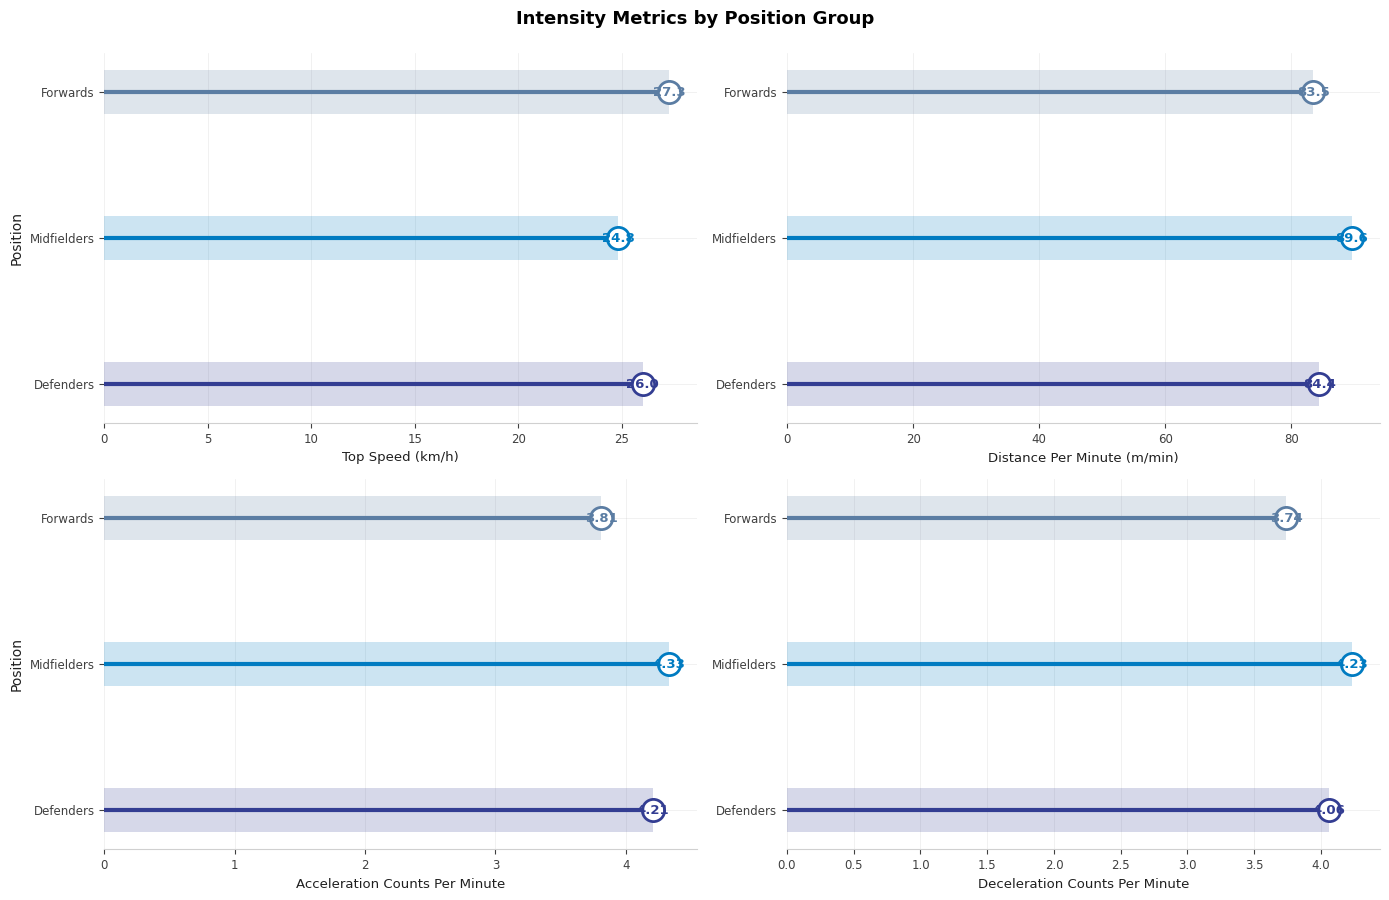

In [43]:
# Professional position group comparison - Intensity metrics with creative styling
metrics_to_plot = [
    ('top_speed_kmh', 'Top Speed (km/h)'),
    ('distance_per_min_mmin', 'Distance Per Minute (m/min)'),
    ('acc_counts_per_min', 'Acceleration Counts Per Minute'),
    ('dec_counts_per_min', 'Deceleration Counts Per Minute')
]

position_order = ['Defenders', 'Midfielders', 'Forwards']
position_colors = [dark_blue, light_blue, '#5B7DA3']

fig, axes = plt.subplots(2, 2, figsize=(14, 9), facecolor='white')

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    
    # Draw horizontal reference lines with gradient colors and creative styling
    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), position_colors):
        # Light background bar for context
        ax.barh(y, val, left=0, height=0.3, color=color, alpha=0.2, edgecolor='none')
        # Main line - thicker and more prominent
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=3)
        # Large hollow marker with border
        ax.plot(val, y, 'o', color=color, markersize=16, markeredgewidth=2, 
               markerfacecolor='white', markeredgecolor=color, zorder=3)
        
        # Format text based on metric
        if metric in ['top_speed_kmh', 'distance_per_min_mmin']:
            text_val = f'{val:.1f}'
        else:
            text_val = f'{val:.2f}'
        
        ax.text(val, y, text_val, va='center', ha='center', fontsize=9.5, 
                color=color, fontweight='700', zorder=4)
    
    # Format axis - professional typography
    ax.set_yticks(y_positions)
    ax.set_yticklabels(position_order, fontsize=9, fontweight='400')
    ax.set_xlabel(xlabel, fontsize=10, fontweight='400', color='#1F1F1F')
    
    # Apply FUFA theme
    apply_fufa_chart_theme(ax, remove_y_labels=False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='x', linestyle='-', alpha=0.15, color='#808080', linewidth=0.5)
    ax.set_axisbelow(True)

axes[0, 0].set_ylabel('Position', fontsize=10, fontweight='400', color='#1F1F1F')
axes[1, 0].set_ylabel('Position', fontsize=10, fontweight='400', color='#1F1F1F')

fig.suptitle('Intensity Metrics by Position Group', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

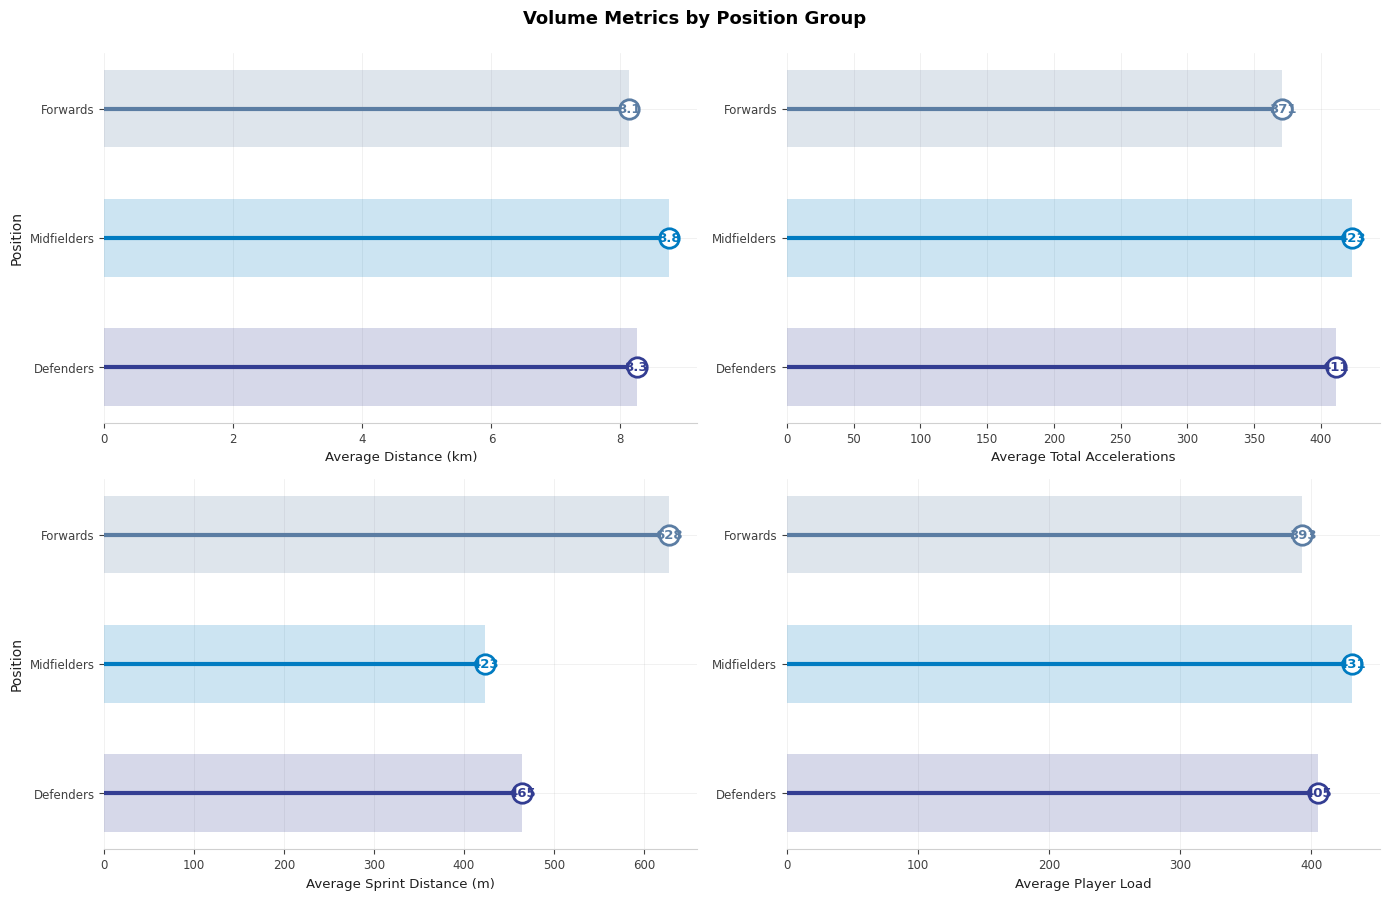

In [44]:
# Professional position group comparison - Volume metrics with creative styling
metrics_to_plot = [
    ('distance_km', 'Average Distance (km)'),
    ('total_accelerations', 'Average Total Accelerations'),
    ('sprint_distance_m', 'Average Sprint Distance (m)'),
    ('player_load', 'Average Player Load')
]

position_order = ['Defenders', 'Midfielders', 'Forwards']
position_colors = [dark_blue, light_blue, '#5B7DA3']

fig, axes = plt.subplots(2, 2, figsize=(14, 9), facecolor='white')

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    
    # Draw horizontal reference lines with gradient colors and creative styling
    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), position_colors):
        # Light background bar for context
        ax.barh(y, val, left=0, height=0.6, color=color, alpha=0.2, edgecolor='none')
        # Main line - thicker
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=3)
        # Large hollow marker with border
        ax.plot(val, y, 'o', color=color, markersize=14, markeredgewidth=2, 
               markerfacecolor='white', markeredgecolor=color, zorder=3)
        
        # Format text based on metric
        if metric == 'distance_km':
            text_val = f'{val:.1f}'
        elif metric == 'sprint_distance_m':
            text_val = f'{val:.0f}'
        elif metric == 'player_load':
            text_val = f'{val:.0f}'
        else:
            text_val = f'{val:.0f}'
        
        ax.text(val, y, text_val, va='center', ha='center', fontsize=9.5, 
                color=color, fontweight='700', zorder=4)
    
    # Format axis - professional typography
    ax.set_yticks(y_positions)
    ax.set_yticklabels(position_order, fontsize=9, fontweight='400')
    ax.set_xlabel(xlabel, fontsize=10, fontweight='400', color='#1F1F1F')
    
    # Apply FUFA theme
    apply_fufa_chart_theme(ax, remove_y_labels=False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='x', linestyle='-', alpha=0.15, color='#808080', linewidth=0.5)
    ax.set_axisbelow(True)

axes[0, 0].set_ylabel('Position', fontsize=10, fontweight='400', color='#1F1F1F')
axes[1, 0].set_ylabel('Position', fontsize=10, fontweight='400', color='#1F1F1F')

fig.suptitle('Volume Metrics by Position Group', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Comparison by Location

In [45]:
# Calculate average volume metrics by location
avg_volume_by_location = df.groupby('location')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_location)

,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
location,,,,,,,
Away,8.360000,497.530000,43.860000,836.270000,6.850000,401.420000,391.310000
Home,8.410000,495.370000,43.880000,837.730000,5.980000,406.510000,395.310000


In [46]:
# Calculate average intensity metrics by location
avg_intensity_by_location = df.groupby('location')[[i for i in intensity_metrics ]].mean()
style_table_for_docs(avg_intensity_by_location)

,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
location,,,,,,,,,
Away,410.658266,25.928181,86.564760,3.873909,19.853560,5.319484,6.665344,4.155587,4.050157
Home,410.346983,26.021062,85.236253,3.657112,18.741237,5.331323,6.513576,4.121469,4.007631


In [47]:
# Calculate max metrics by location
avg_intensity_by_location_ = df.groupby('location')[['top_speed_kmh','distance_per_min_mmin']].max().round(2)
style_table_for_docs(avg_intensity_by_location_)

,top_speed_kmh,distance_per_min_mmin
location,,
Away,31.930000,116.750000
Home,32.350000,111.640000


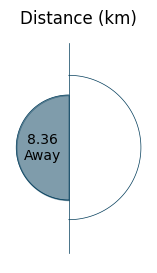

In [48]:
def plot_home_away_top_speed(avg_volume_by_location, color='#003b59', min_radius=0.8, max_radius=1.1):
    """
    Plot a semicircle comparison of top speed (km/h) for Home vs Away using avg_volume_by_location DataFrame.
    """
    home_speed = avg_volume_by_location.loc['Home', 'distance_km']
    away_speed = avg_volume_by_location.loc['Away', 'distance_km']

    speeds = np.array([home_speed, away_speed])
    norm_radii = min_radius + (speeds - speeds.min()) / (speeds.max() - speeds.min()) * (max_radius - min_radius)
    home_radius, away_radius = norm_radii

    fig, ax = plt.subplots(figsize=(3, 3))
    ax.set_aspect('equal')
    ax.axis('off')

    # Draw right (Home) semicircle
    theta_home = np.linspace(-np.pi/2, np.pi/2, 100)
    x_home = home_radius * np.cos(theta_home)
    y_home = home_radius * np.sin(theta_home)
    ax.plot(x_home, y_home, color=color, linewidth=0.5)
    if home_radius < away_radius:
        ax.fill_betweenx(y_home, 0, x_home, color=color, alpha=0.5)

    # Draw left (Away) semicircle
    theta_away = np.linspace(np.pi/2, 3*np.pi/2, 100)
    x_away = away_radius * np.cos(theta_away)
    y_away = away_radius * np.sin(theta_away)
    ax.plot(x_away, y_away, color=color, linewidth=0.5)
    if away_radius < home_radius:
        ax.fill_betweenx(y_away, x_away, 0, color=color, alpha=0.5)

    # Draw the separating line
    ax.plot([0, 0], [-max(home_radius+0.5, away_radius+0.5), max(home_radius+0.5, away_radius+0.5)], color=color, linewidth=0.5, zorder=3)

    # Place values inside semicircles
    ax.text(home_radius * 0.5, 0, f"{home_speed:.2f}\nHome", ha='center', va='center', fontsize=10, color='#fff', fontweight='normal')
    ax.text(-away_radius * 0.5, 0, f"{away_speed:.2f}\nAway", ha='center', va='center', fontsize=10, color='#000', fontweight='normal')

    plt.title('Distance (km)', fontsize=12)
    plt.show()
plot_home_away_top_speed(avg_volume_by_location)

### Metric Distribution 

In [49]:
df.columns[:20]

Index(['p_name', 'club_for', 'club_against', 'player_club_', 'match_day',
       'general_position', 'player_position', 'result', 'location', 'duration',
       'distance_km', 'sprint_distance_m', 'power_plays', 'energy_kcal',
       'impacts', 'player_load', 'top_speed_kmh', 'max_acceleration_mss',
       'max_deceleration_mss', 'distance_per_min_mmin'],
      dtype='object')

In [50]:
df.columns[-5:]

Index(['time_in_speed_zone_5_secs', 'total_accelerations',
       'total_decelerations', 'acc_counts_per_min', 'dec_counts_per_min'],
      dtype='object')

In [51]:
derived_metrics = ['total_accelerations','total_decelerations','acc_counts_per_min','dec_counts_per_min']
for i in derived_metrics:
    num_cols.append(i)

In [52]:
num_cols.remove('max_acceleration_mss')
num_cols.remove('max_deceleration_mss')

In [53]:
num_cols.remove('duration')

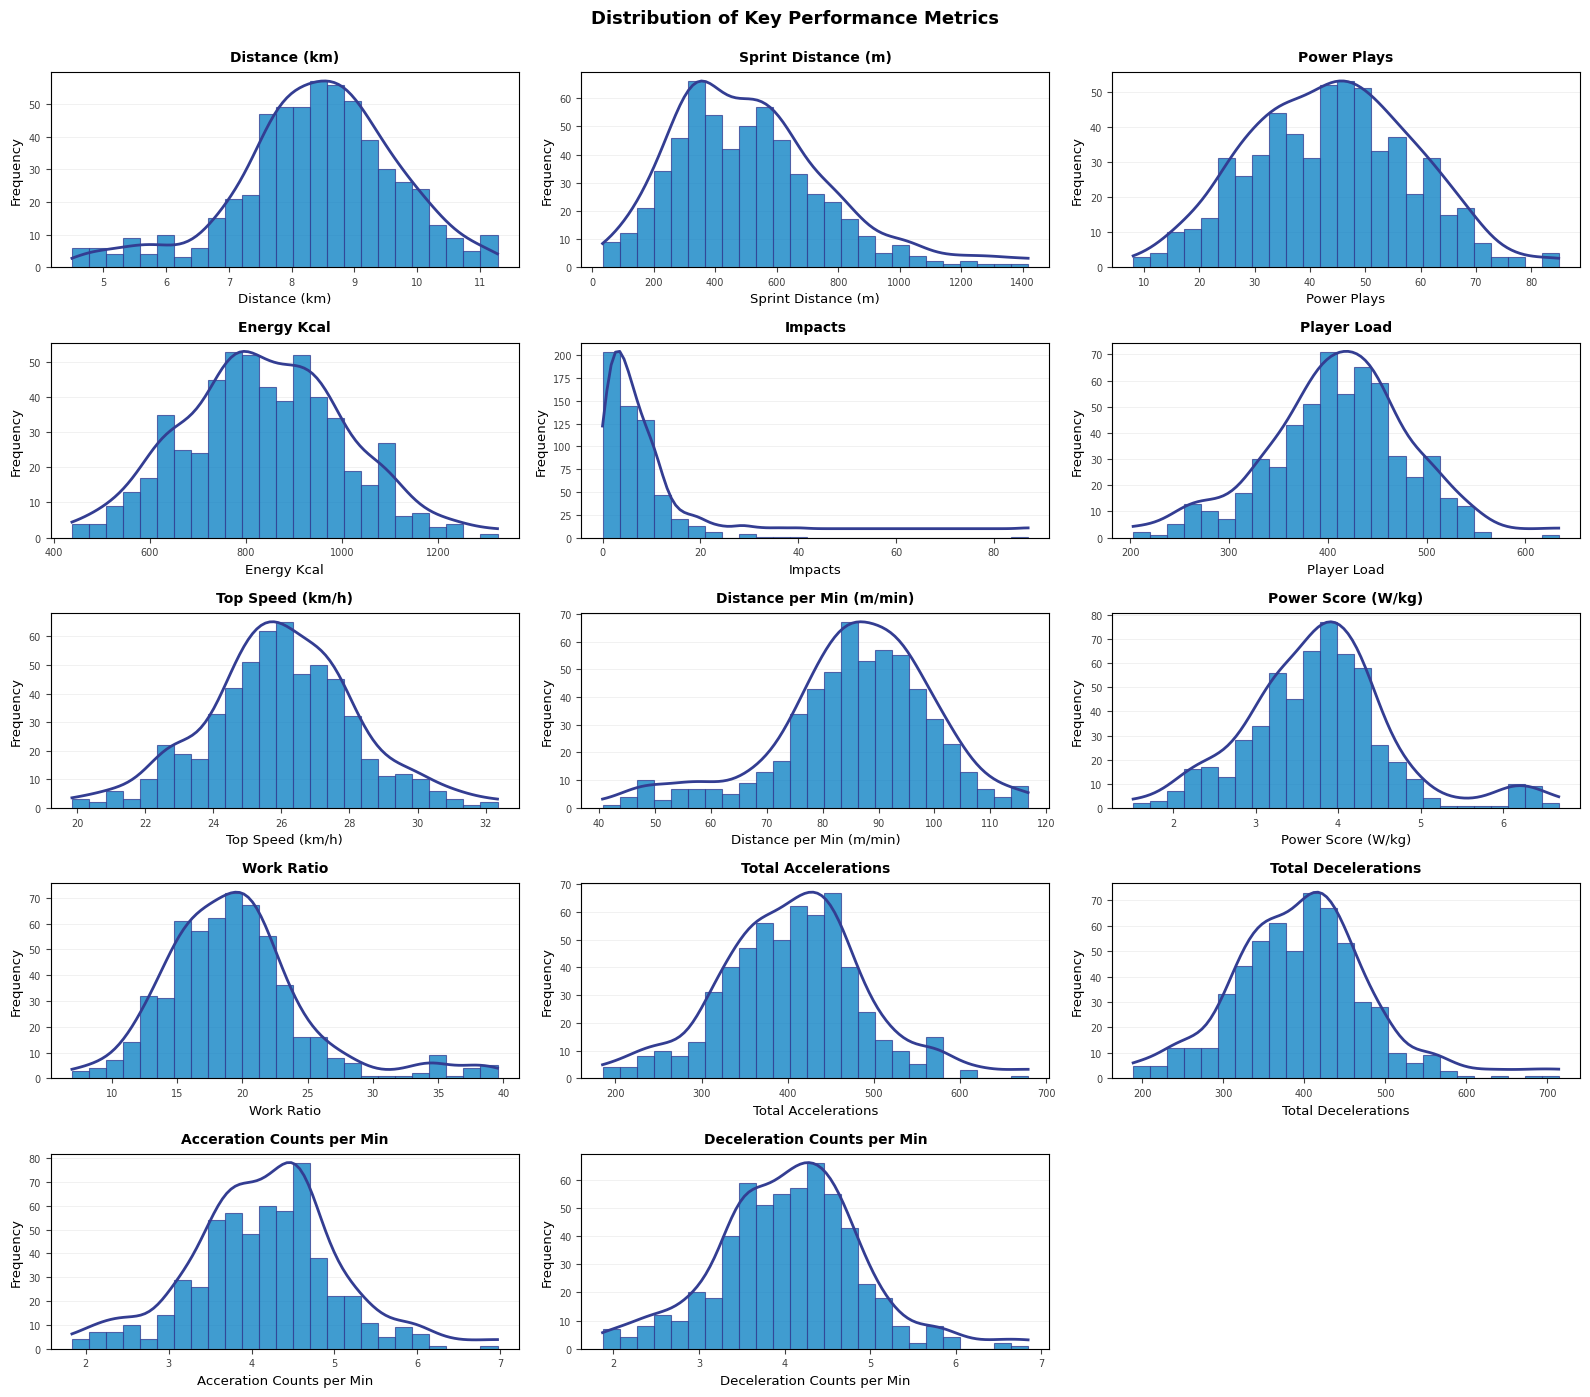

In [54]:
plt.figure(figsize=(16, 14), facecolor='white')

for i, col in enumerate(num_cols):
    ax = plt.subplot(5, 3, i + 1)
    
    # Create histogram with FUFA colors
    n, bins, patches = ax.hist(df[col].dropna(), bins=25, color=light_blue, alpha=0.75, 
                               edgecolor=dark_blue, linewidth=0.8)
    
    # Add KDE line in dark blue
    from scipy import stats
    kde = stats.gaussian_kde(df[col].dropna())
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    ax2 = ax.twinx()
    ax2.plot(x_range, kde(x_range), color=dark_blue, linewidth=2, label='Density')
    ax2.set_ylabel('')
    ax2.set_yticks([])
    
    # Format title and x-label
    label = col.replace('_', ' ').title()
    if col == 'distance_km':
        label = 'Distance (km)'
    elif col == 'sprint_distance_m':
        label = 'Sprint Distance (m)'
    elif col == 'top_speed_kmh':
        label = 'Top Speed (km/h)'
    elif col == 'distance_per_min_mmin':
        label = 'Distance per Min (m/min)'
    elif col == 'power_score_wkg':
        label = 'Power Score (W/kg)'
    elif col == 'total_decelerations':
        label = 'Total Decelerations'
    elif col == 'total_accelerations':
        label = 'Total Accelerations'
    elif col == 'acc_counts_per_min':
        label = 'Acceration Counts per Min'
    elif col == 'dec_counts_per_min':
        label = 'Deceleration Counts per Min'
    
    ax.set_title(f'{label}', fontsize=10, fontweight='600', pad=8)
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)
    
    # Apply professional styling
    apply_fufa_chart_theme(ax, remove_y_labels=False)
    ax.tick_params(labelsize=7)

plt.suptitle('Distribution of Key Performance Metrics', fontsize=13, fontweight='700', y=0.995)
plt.tight_layout()
plt.show()


## Trend Analysis

In [55]:
avg_volume_per_matchday = df.groupby('match_day')[volume_metrics + intensity_metrics].mean().reset_index()
# Ensure 'match_day' is a categorical variable with the correct order
avg_volume_per_matchday['match_day'] = pd.Categorical(
    avg_volume_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
avg_volume_per_matchday = avg_volume_per_matchday.sort_values(by='match_day').round(2)
style_table_for_docs(avg_volume_per_matchday)

,match_day,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,Md1,8.180000,413.170000,41.040000,822.670000,5.440000,416.290000,405.920000,405.850000,25.750000,82.780000,3.730000,19.300000,5.330000,6.490000,4.210000,4.110000
3,Md2,8.300000,505.820000,43.560000,830.870000,5.850000,393.110000,382.220000,404.800000,26.130000,84.010000,3.940000,20.210000,5.300000,6.520000,3.980000,3.870000
4,Md3,7.810000,444.940000,40.330000,791.700000,5.580000,379.780000,369.470000,379.430000,25.810000,80.340000,3.390000,17.120000,5.240000,6.700000,3.910000,3.810000
5,Md4,9.100000,503.080000,46.290000,884.140000,7.140000,431.950000,419.440000,446.630000,25.440000,93.960000,4.600000,24.420000,5.370000,6.450000,4.460000,4.330000
6,Md5,8.310000,453.200000,41.370000,833.870000,5.130000,421.390000,409.240000,411.730000,25.560000,83.370000,3.680000,18.630000,5.240000,6.410000,4.240000,4.110000
7,Md6,8.540000,559.380000,47.860000,842.040000,7.100000,404.710000,392.670000,411.230000,26.480000,88.510000,4.000000,20.530000,5.440000,6.940000,4.200000,4.070000
8,Md7,8.300000,459.690000,43.560000,827.500000,7.660000,409.980000,405.930000,410.040000,25.640000,84.930000,3.560000,17.920000,5.330000,6.670000,4.190000,4.150000
9,Md8,8.430000,583.650000,46.480000,845.060000,5.610000,380.960000,368.830000,403.870000,26.420000,88.870000,3.700000,18.920000,5.410000,6.760000,4.020000,3.890000
10,Md9,8.340000,497.330000,42.480000,824.470000,8.150000,399.630000,389.440000,410.270000,26.450000,85.160000,3.630000,18.930000,5.370000,6.620000,4.080000,3.980000
1,Md10,8.410000,515.400000,44.190000,846.410000,6.660000,394.340000,384.130000,412.580000,26.000000,85.160000,3.260000,16.630000,5.250000,6.290000,3.990000,3.890000


In [56]:
# Sort by match_day using the correct order
df['match_day'] = pd.Categorical(df['match_day'], categories=matchday_order, ordered=True)
df_sorted = df.sort_values('match_day')

# Compute rolling mean for each metric per match day
rolling_avg = (
    df_sorted.groupby('match_day', observed=True)[volume_metrics + intensity_metrics]
    .mean()
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index()
)

rolling_avg['match_day'] = pd.Categorical(rolling_avg['match_day'], categories=matchday_order, ordered=True)
rolling_avg = rolling_avg.sort_values(by='match_day').round(2)
style_table_for_docs(rolling_avg)

,match_day,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,Md1,8.180000,413.170000,41.040000,822.670000,5.440000,416.290000,405.920000,405.850000,25.750000,82.780000,3.730000,19.300000,5.330000,6.490000,4.210000,4.110000
1,Md2,8.240000,459.490000,42.300000,826.770000,5.650000,404.700000,394.070000,405.320000,25.940000,83.390000,3.830000,19.750000,5.310000,6.510000,4.100000,3.990000
2,Md3,8.100000,454.640000,41.640000,815.080000,5.620000,396.390000,385.870000,396.690000,25.900000,82.370000,3.690000,18.870000,5.290000,6.570000,4.030000,3.930000
3,Md4,8.400000,484.610000,43.390000,835.570000,6.190000,401.610000,390.380000,410.290000,25.790000,86.100000,3.980000,20.580000,5.300000,6.560000,4.120000,4.000000
4,Md5,8.410000,467.070000,42.660000,836.570000,5.950000,411.040000,399.380000,412.600000,25.600000,85.890000,3.890000,20.060000,5.280000,6.520000,4.200000,4.080000
5,Md6,8.650000,505.220000,45.170000,853.350000,6.460000,419.350000,407.120000,423.200000,25.830000,88.620000,4.090000,21.190000,5.350000,6.600000,4.300000,4.170000
6,Md7,8.380000,490.750000,44.260000,834.470000,6.630000,412.030000,402.610000,411.000000,25.890000,85.600000,3.750000,19.030000,5.340000,6.680000,4.210000,4.110000
7,Md8,8.420000,534.240000,45.970000,838.200000,6.790000,398.550000,389.140000,408.380000,26.180000,87.440000,3.750000,19.120000,5.390000,6.790000,4.130000,4.040000
8,Md9,8.360000,513.550000,44.170000,832.340000,7.140000,396.860000,388.070000,408.060000,26.170000,86.320000,3.630000,18.590000,5.370000,6.680000,4.100000,4.000000
9,Md10,8.390000,532.120000,44.380000,838.640000,6.810000,391.640000,380.800000,408.910000,26.290000,86.400000,3.530000,18.160000,5.340000,6.560000,4.030000,3.920000


In [57]:
# fig, axes = plt.subplots(2, 2, figsize=(16, 10))
# metrics = [
#     ('distance_km', 'Distance (km)'),
#     ('sprint_distance_m', 'Sprint Distance (m)'),
#     ('player_load', 'Player Load'),
#     ('top_speed_kmh', 'Top Speed (km/h)')
# ]

# # Get valid match days (non-NaN)
# valid_matchdays = rolling_avg['match_day'].dropna().tolist()
# MD11_idx = valid_matchdays.index('MD11') if 'MD11' in valid_matchdays else None
# last_idx = len(valid_matchdays) - 1

# for ax, (col, label) in zip(axes.flatten(), metrics):
#     sns.lineplot(
#         data=rolling_avg,
#         x='match_day',
#         y=col,
#         marker='o',
#         ax=ax,
#         label=f'Average {label}'
#     )
#     avg_value = rolling_avg[col].mean()
#     ax.axhline(avg_value, color='red', linestyle='--', label=f'Season Average: {avg_value:.2f}')
#     # Draw vertical line at MD11
#     ax.axvline(MD11_idx, color='black', linestyle=':', linewidth=1)
#     # Shade area before MD11 (First Round)
#     ax.axvspan(-0.5, MD11_idx - 0.5, color='skyblue', alpha=0.35)
#     # Shade area from MD11 to last matchday (Second Round)
#     ax.axvspan(MD11_idx - 0.5, last_idx + 0.5, color='lightgreen', alpha=0.35)
#     xticklabels = [str(Wmd).replace('MD', 'MD ') for Wmd in valid_matchdays]
#     ax.set_xticks(range(len(valid_matchdays)))
#     ax.set_xticklabels(xticklabels, rotation=90)
#     ax.set_title(f'{label} Across Match Days')
#     ax.set_xlabel('Match Day')
#     ax.set_ylabel(label)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     legend = ax.legend(frameon=False)
#     ymin, ymax = ax.get_ylim()
#     ax.text(MD11_idx/2, avg_value - (ymax-ymin)*0.12, 'First Round', color='blue', fontsize=12, ha='center', va='top', alpha=0.7)
#     ax.text(MD11_idx + (last_idx-MD11_idx)/2, avg_value + (ymax-ymin)*0.08, 'Second Round', color='green', fontsize=12, ha='center', va='bottom', alpha=0.7)

# plt.tight_layout(rect=[0, 0.01, 1, 1])
# plt.figtext(0.5, 0.01, "Note: All values are from a 3-match rolling average.", ha='center', fontsize=12, style='italic')
# plt.show()


## Correlation Analysis

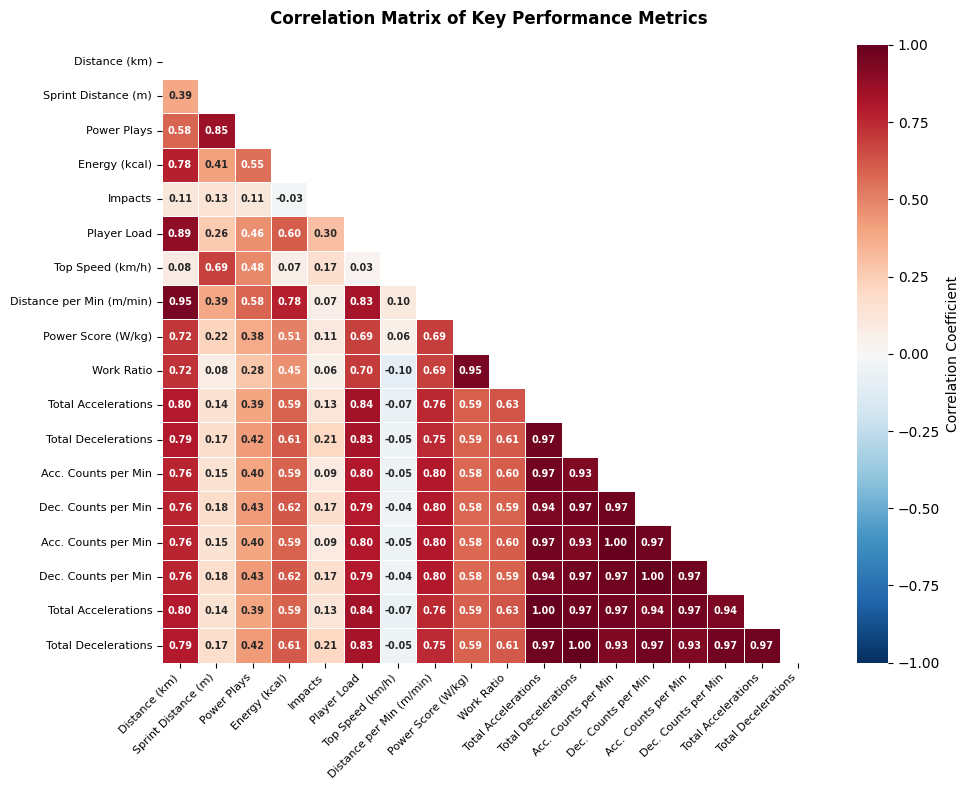

In [58]:
cols_to_corr = [col for col in num_cols if col != 'duration']
cols_to_corr.extend(['acc_counts_per_min','dec_counts_per_min','total_accelerations','total_decelerations'])
corr = df[cols_to_corr].corr(method='pearson')

# Mapping for pretty axis labels
pretty_labels = {
    'distance_km': 'Distance (km)',
    'sprint_distance_m': 'Sprint Distance (m)',
    'power_plays': 'Power Plays',
    'energy_kcal': 'Energy (kcal)',
    'impacts': 'Impacts',
    'player_load': 'Player Load',
    'top_speed_kmh': 'Top Speed (km/h)',
    'distance_per_min_mmin': 'Distance per Min (m/min)',
    'power_score_wkg': 'Power Score (W/kg)',
    'work_ratio': 'Work Ratio',
    'max_acceleration_mss': 'Max Acceleration (m/s²)',
    'max_deceleration_mss': 'Max Deceleration (m/s²)',
    'acc_counts_per_min':'Acc. Counts per Min',
    'dec_counts_per_min':'Dec. Counts per Min',
    'total_accelerations': 'Total Accelerations',
    'total_decelerations': 'Total Decelerations'
}

# Re-label the correlation matrix
corr = corr.rename(index=pretty_labels, columns=pretty_labels)

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    fmt='.2f',
    linewidths=0.5,
    linecolor='white',
    mask=mask,
    cbar_kws={'label': 'Correlation Coefficient'},
    ax=ax,
    annot_kws={'fontsize': 7, 'fontweight': 'bold'}
)

ax.set_title('Correlation Matrix of Key Performance Metrics', fontsize=12, fontweight='700', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()


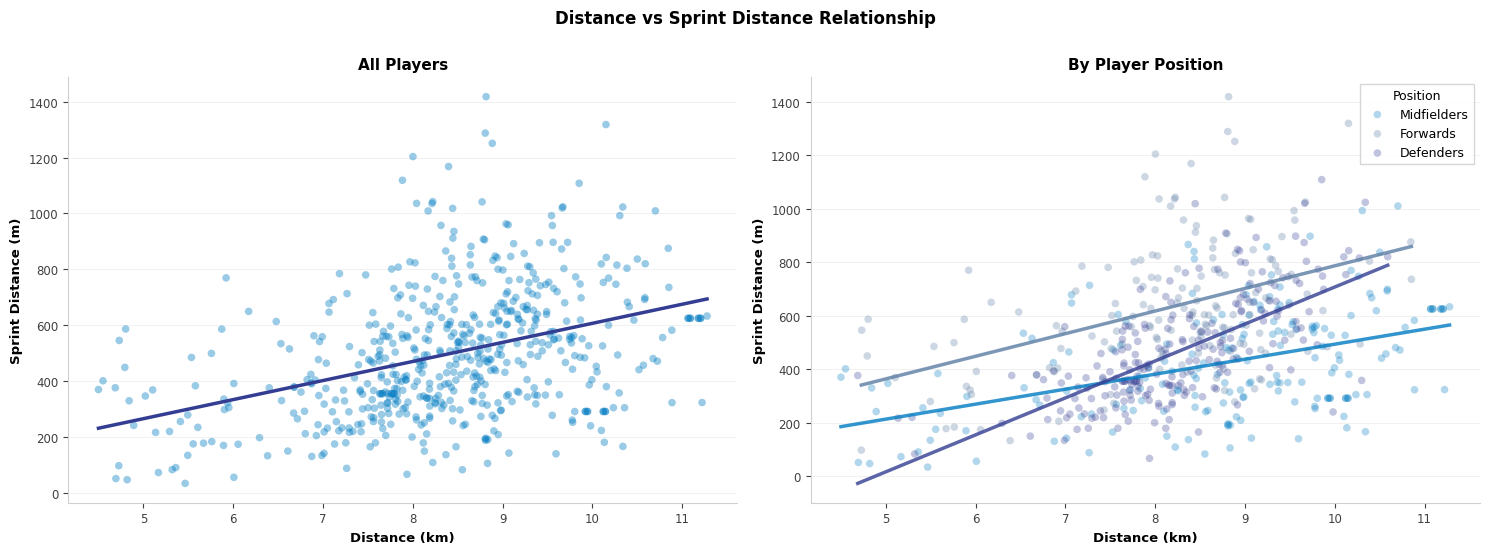

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), facecolor='white')

# Plot 1: All players, no hue
ax1 = axes[0]
ax1.scatter(df['distance_km'], df['sprint_distance_m'], alpha=0.4, color=light_blue, s=30, edgecolors='none')

# Add regression line in dark blue
from scipy import stats as sp_stats
z = np.polyfit(df['distance_km'].dropna(), df.loc[df['distance_km'].notna(), 'sprint_distance_m'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['distance_km'].min(), df['distance_km'].max(), 100)
ax1.plot(x_line, p(x_line), color=dark_blue, linewidth=2.5, label='Trend')

ax1.set_xlabel('Distance (km)', fontsize=10, fontweight='600')
ax1.set_ylabel('Sprint Distance (m)', fontsize=10, fontweight='600')
ax1.set_title('All Players', fontsize=11, fontweight='600')
apply_fufa_chart_theme(ax1)

# Plot 2: Hue by player position with trend lines
ax2 = axes[1]
position_colors_dict = {'Defenders': dark_blue, 'Midfielders': light_blue, 'Forwards': '#5B7DA3'}

for pos in df['general_position'].dropna().unique():
    data_subset = df[df['general_position'] == pos]
    ax2.scatter(data_subset['distance_km'], data_subset['sprint_distance_m'], 
               alpha=0.3, color=position_colors_dict.get(pos, dark_blue), s=30, 
               label=pos, edgecolors='none')
    
    # Add trend line for each position
    if len(data_subset) > 1:
        z = np.polyfit(data_subset['distance_km'].dropna(), 
                      data_subset.loc[data_subset['distance_km'].notna(), 'sprint_distance_m'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(data_subset['distance_km'].min(), data_subset['distance_km'].max(), 50)
        ax2.plot(x_line, p(x_line), color=position_colors_dict.get(pos, dark_blue), 
                linewidth=2.5, linestyle='-', alpha=0.8)

ax2.set_xlabel('Distance (km)', fontsize=10, fontweight='600')
ax2.set_ylabel('Sprint Distance (m)', fontsize=10, fontweight='600')
ax2.set_title('By Player Position', fontsize=11, fontweight='600')
apply_fufa_chart_theme(ax2)
ax2.legend(title='Position', frameon=True, fancybox=False, shadow=False, fontsize=9, title_fontsize=9)

fig.suptitle('Distance vs Sprint Distance Relationship', fontsize=12, fontweight='700', y=1.00)
plt.tight_layout()
plt.show()


## Other Requests

### Pairwise Performance

In [60]:
# # Calculate and display the average distance covered by players of both teams when they play each other, for all pairs

# clubs = sorted(df['club_for'].unique())
# single_matchday_metric = []

# for i, club1 in enumerate(clubs):
#     for club2 in clubs[i+1:]:
#         # Find all matchdays where these two clubs played each other
#         matchdays = df[
#             ((df['club_for'] == club1) & (df['club_against'] == club2)) |
#             ((df['club_for'] == club2) & (df['club_against'] == club1))
#         ]['match_day'].unique()
#         for md in matchdays:
#             # Filter for only this pair and this matchday
#             mask = (
#                 (((df['club_for'] == club1) & (df['club_against'] == club2)) |
#                  ((df['club_for'] == club2) & (df['club_against'] == club1))) &
#                 (df['match_day'] == md)
#             )
#             relevant_rows = df[mask]
#             if not relevant_rows.empty:
#                 avg_metrics = relevant_rows[intensity_metrics+volume_metrics].mean()
#                 row = {
#                     'Team A': club1,
#                     'Team B': club2,
#                     'match_day': md
#                 }
#                 row.update(avg_metrics.to_dict())
#                 single_matchday_metric.append(row)

# single_matchday_metric_df = pd.DataFrame(single_matchday_metric)
# single_matchday_metric_df = single_matchday_metric_df[
#     (single_matchday_metric_df['top_speed_kmh'] > 20)
# ][['Team A', 'Team B', 'match_day', 'top_speed_kmh', 'player_load','distance_km']]
# single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['distance_km'] > 8)]
# single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['player_load'] > 300)]
# single_matchday_metric_df = single_matchday_metric_df.sort_values(by='player_load', ascending=False).reset_index(drop=True)

# style_table_for_docs(single_matchday_metric_df.head(10))

In [61]:
# # Calculate and display the average distance covered by players of both teams when they play each other, for all pairs

# clubs = sorted(df['club_for'].unique())
# single_matchday_metric = []

# for i, club1 in enumerate(clubs):
#     for club2 in clubs[i+1:]:
#         # Find all matchdays where these two clubs played each other
#         matchdays = df[
#             ((df['club_for'] == club1) & (df['club_against'] == club2)) |
#             ((df['club_for'] == club2) & (df['club_against'] == club1))
#         ]['match_day'].unique()
#         for md in matchdays:
#             # Filter for only this pair and this matchday
#             mask = (
#                 (((df['club_for'] == club1) & (df['club_against'] == club2)) |
#                  ((df['club_for'] == club2) & (df['club_against'] == club1))) &
#                 (df['match_day'] == md)
#             )
#             relevant_rows = df[mask]
#             if not relevant_rows.empty:
#                 avg_metrics = relevant_rows[intensity_metrics+volume_metrics].mean()
#                 row = {
#                     'Team A': club1,
#                     'Team B': club2,
#                     'match_day': md
#                 }
#                 row.update(avg_metrics.to_dict())
#                 single_matchday_metric.append(row)

# single_matchday_metric_df = pd.DataFrame(single_matchday_metric)
# single_matchday_metric_df = single_matchday_metric_df[
#     (single_matchday_metric_df['top_speed_kmh'] > 0)
# ][['Team A', 'Team B', 'match_day', 'top_speed_kmh', 'player_load','distance_km']]
# single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['distance_km'] < 9)]
# single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['player_load'] < 400)]
# single_matchday_metric_df = single_matchday_metric_df.sort_values(by='distance_km', ascending=True).reset_index(drop=True)

# style_table_for_docs(single_matchday_metric_df.head(10))

In [62]:
# # Create a DataFrame showing the averages of all intensity metrics for each team A when they play team B
# clubs = sorted(df['club_for'].unique())
# avg_intensity_vs_opponent = []

# for club1 in clubs:
#     for club2 in clubs:
#         if club1 == club2:
#             continue  # skip self
#         mask = (
#             ((df['club_for'] == club1) & (df['club_against'] == club2))
#         )
#         club1_rows = df[mask]
#         if not club1_rows.empty:
#             avg_metrics = club1_rows[intensity_metrics].mean()
#             row = {'Team A': club1, 'Team B': club2}
#             row.update(avg_metrics.to_dict())
#             avg_intensity_vs_opponent.append(row)

# avg_intensity_vs_opponent_df = pd.DataFrame(avg_intensity_vs_opponent)
# avg_intensity_vs_opponent_df = avg_intensity_vs_opponent_df.sort_values(by='top_speed_kmh', ascending=False).reset_index(drop=True)
# style_table_for_docs(avg_intensity_vs_opponent_df.head(10))

In [63]:
# # Create a DataFrame showing the averages of all volume metrics for each team A when they play team B
# clubs = sorted(df['club_for'].unique())
# avg_volume_vs_opponent = []

# for club1 in clubs:
#     for club2 in clubs:
#         if club1 == club2:
#             continue  # skip self
#         mask = (
#             ((df['club_for'] == club1) & (df['club_against'] == club2))
#         )
#         club1_rows = df[mask]
#         if not club1_rows.empty:
#             avg_metrics = club1_rows[volume_metrics].mean()
#             row = {'Team A': club1, 'Team B': club2}
#             row.update(avg_metrics.to_dict())
#             avg_volume_vs_opponent.append(row)

# avg_volume_vs_opponent_df = pd.DataFrame(avg_volume_vs_opponent)
# avg_volume_vs_opponent_df = avg_volume_vs_opponent_df.sort_values(by='distance_km', ascending=False).reset_index(drop=True)
# style_table_for_docs(avg_volume_vs_opponent_df.head(10))

### Top Performers for each Metric (Individual/ Team/ Pairwise)

In [64]:
# # Find top 5 players for each metric in volume_metrics and intensity_metrics
# top5_players = []

# metrics_to_check = volume_metrics + intensity_metrics
# for metric in metrics_to_check:
#     # Get top 5 rows for this metric
#     top_rows = df.nlargest(5, metric)
#     for _, row in top_rows.iterrows():
#         top5_players.append({
#             'metric': metric,
#             'player': row['p_name'],
#             'club': row['club_for'],
#             'value': row[metric],
#             'match day': row['match_day']
#         })

# top5_players_df = pd.DataFrame(top5_players)
# # Optionally, sort for display
# top5_players_df = top5_players_df.sort_values(['metric', 'value'], ascending=[True, False]).reset_index(drop=True)
# style_table_for_docs(top5_players_df)

### Best Performers in each position

In [65]:
# # Combine metrics into one list
# all_metrics = volume_metrics + intensity_metrics

# # Store top 5 players per metric and position
# top5_players_by_position = []

# for metric in all_metrics:
#     for position in df['general_position'].dropna().unique():
#         # Get top 5 players for this metric and position
#         top_rows = df[df['general_position'] == position].nlargest(5, metric)
        
#         for _, row in top_rows.iterrows():
#             top5_players_by_position.append({
#                 'metric': metric,
#                 'player': row['p_name'],
#                 'club': row['club_for'],
#                 'value': row[metric],
#                 'match day': row['match_day'],
#                 'position': position
#             })

# # Convert to DataFrame
# top5_players_by_position_df = pd.DataFrame(top5_players_by_position)

# # Sort by metric name (alphabetically) and then value (descending)
# top5_players_by_position_df = top5_players_by_position_df.sort_values(
#     ['metric', 'value'], ascending=[True, False]
# ).reset_index(drop=True)

# # Apply your styling function
# style_table_for_docs(top5_players_by_position_df)



In [66]:
# # Combine metrics into one list
# all_metrics = volume_metrics + intensity_metrics

# # Group by player and position, then average all metrics
# avg_df = df.groupby(['p_name', 'general_position', 'club_for'])[all_metrics].mean().reset_index()

# # Store top 5 players per metric and position
# top5_players_by_position = []

# for metric in all_metrics:
#     for position in avg_df['general_position'].dropna().unique():
#         # Get top 5 players for this metric and position
#         top_rows = avg_df[avg_df['general_position'] == position].nlargest(5, metric)
        
#         for _, row in top_rows.iterrows():
#             top5_players_by_position.append({
#                 'metric': metric,
#                 'player': row['p_name'],
#                 'club': row['club_for'],
#                 'value': row[metric],
#                 'position': position
#             })

# # Convert to DataFrame
# top5_players_by_position_df = pd.DataFrame(top5_players_by_position)

# # Sort for display: alphabetically by metric, descending by value
# top5_players_by_position_df = top5_players_by_position_df.sort_values(
#     ['metric', 'value'], ascending=[True, False]
# ).reset_index(drop=True)

# # Display nicely (assuming this is your custom function)
# style_table_for_docs(top5_players_by_position_df)


In [67]:
# # Custom position sorting order
# position_order = ['Defenders', 'Midfielders', 'Forwards']

# # Step 1: Count appearances (unique match days)
# appearances_df = df.groupby(['p_name', 'general_position', 'club_for'])['match_day'].nunique().reset_index()
# appearances_df = appearances_df.rename(columns={'match_day': 'appearances'})

# # Step 2: Calculate mean and std for metrics
# metrics_stats_df = df.groupby(['p_name', 'general_position', 'club_for'])[all_metrics].agg(['mean', 'std']).reset_index()

# # Step 3: Fix column names: flatten multi-index columns
# metrics_stats_df.columns = [
#     f"{metric}_{stat}" if stat else metric
#     for metric, stat in metrics_stats_df.columns.to_flat_index()
# ]

# # Step 4: Merge with appearances
# merged_df = metrics_stats_df.merge(
#     appearances_df,
#     on=['p_name', 'general_position', 'club_for']
# )

# # Step 5: Only include players with at least 3 appearances
# filtered_df = merged_df[merged_df['appearances'] >= 15]

# # Step 6: Extract top 5 players for each metric and position
# top5_players_by_position = []

# for metric in all_metrics:
#     mean_col = f'{metric}_mean'
#     std_col = f'{metric}_std'

#     for position in position_order:
#         group = filtered_df[filtered_df['general_position'] == position]

#         # Skip if metric column is missing
#         if mean_col not in group.columns:
#             continue

#         top_rows = group.nlargest(5, mean_col)

#         for _, row in top_rows.iterrows():
#             top5_players_by_position.append({
#                 'metric': metric,
#                 'player': row['p_name'],
#                 'club': row['club_for'],
#                 'mean_value': row[mean_col],
#                 'std_dev': row[std_col],
#                 'appearances': row['appearances'],
#                 'position': position
#             })

# # Step 7: Create and sort final DataFrame
# top5_df = pd.DataFrame(top5_players_by_position)

# # Sort positions using custom category
# top5_df['position'] = pd.Categorical(
#     top5_df['position'], categories=position_order, ordered=True
# )

# # Sort by metric → position → mean value
# top5_df = top5_df.sort_values(['metric', 'position', 'mean_value'], ascending=[True, True, False]).reset_index(drop=True)

# # Show results
# style_table_for_docs(top5_df.round(2))


## Speed Zones

### Distance in Speed Zones

In [68]:
# # List of speed zone columns
# speed_zone_cols = [
#     'distance_in_speed_zone_1_km',
#     'distance_in_speed_zone_2_km',
#     'distance_in_speed_zone_3_km',
#     'distance_in_speed_zone_4_km',
#     'distance_in_speed_zone_5_km'
# ]

# # Compute average distance for each speed zone
# avg_speed_zone_dist = df[speed_zone_cols].mean()

# # Prepare labels (replace _ with space, add zone number)
# zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]

# plt.figure(figsize=(8, 5))


# # Create barplot
# # plt.figure(figsize=(12,6))
# sns.barplot(x=zone_labels,hue=zone_labels, y=avg_speed_zone_dist.values, palette='Blues_d',legend=False)

# # Title, subtitle, and axis labels
# # plt.ylabel("Average Distance (m)")
# plt.xlabel("Speed Zone")
# plt.title("Average Distance(m) Covered in Each Speed Zone (All Players)", pad=30)

# ax= plt.gca()

# # Gridlines for y-axis
# ax.yaxis.grid(True, linestyle='--', alpha=0.5)
# ax.set_axisbelow(True)

# # Remove top and right spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_visible(False)

# # Annotate values inside bars
# for i, v in enumerate(avg_speed_zone_dist):
#     # Convert km to m and format with comma

#     ax.annotate(
#         f"{int(round(v),):,}",
#         xy=(i, v),
#         xytext=(0, 1),
#         textcoords='offset points',
#         ha='center',
#         va='bottom',
#         fontsize=9,
#         bbox=dict(boxstyle="circle,pad=0.15", edgecolor='#4682B4', facecolor='white', linewidth=1)
#     )

# #remove yaxis ticklabels
# ax.set_yticklabels([])
# ax.set_yticks([])

# plt.show()


C:\Users\Travail\AppData\Local\Temp\ipykernel_11968\606275136.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(zone_labels, fontsize=9, fontweight='400')


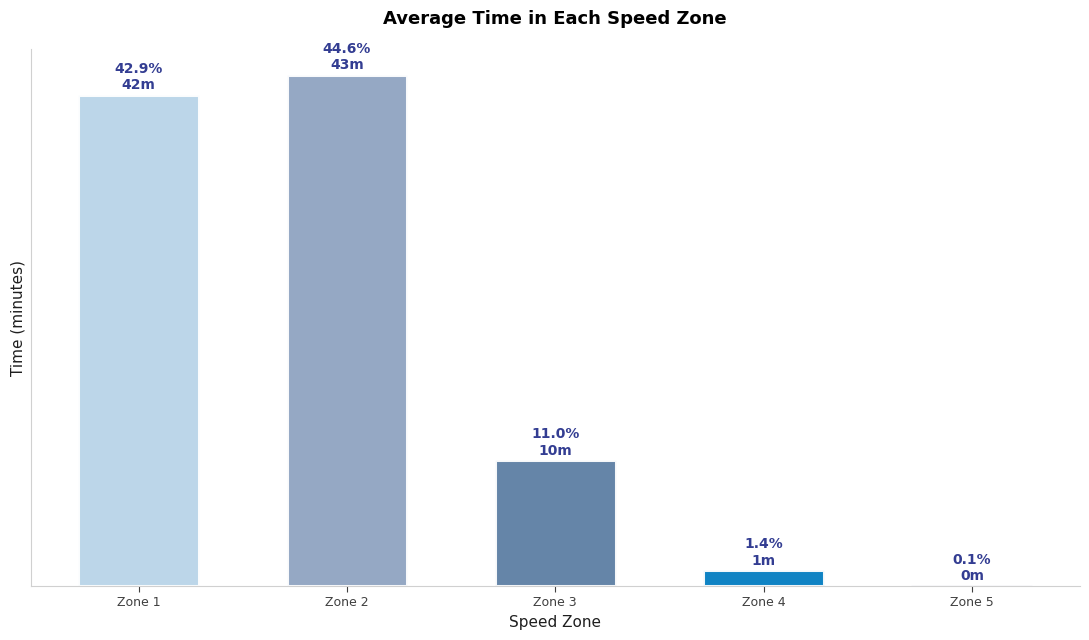

In [69]:
# Speed zones - Time distribution with creative styling
speed_zone_cols = [
    'time_in_speed_zone_1_secs',
    'time_in_speed_zone_2_secs',
    'time_in_speed_zone_3_secs',
    'time_in_speed_zone_4_secs',
    'time_in_speed_zone_5_secs'
]

# Compute average time (secs) for each speed zone
avg_time_secs = df[speed_zone_cols].mean()
total_time = avg_time_secs.sum()

# Prepare labels
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]

# Create professional FUFA color gradient from light to dark blue
zone_colors = ['#B8D4E8', '#8FA3C1', '#5B7DA3', light_blue, dark_blue]

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='white')
bars = ax.bar(zone_labels, avg_time_secs.values / 60, color=zone_colors, 
             edgecolor='white', linewidth=2.2, width=0.58, alpha=0.94)

# Apply FUFA theme
apply_fufa_chart_theme(ax, remove_y_ticks=True, remove_y_labels=True)

ax.set_xlabel('Speed Zone', fontsize=11, fontweight='400', color='#1F1F1F')
ax.set_ylabel('Time (minutes)', fontsize=11, fontweight='400', color='#1F1F1F')
ax.set_title('Average Time in Each Speed Zone', fontsize=13, fontweight='bold', pad=18)

# Annotate with percentages and time above bars
for i, secs in enumerate(avg_time_secs):
    pct = (secs / total_time) * 100
    mins = int(secs // 60)
    ax.text(
        i, 
        (secs / 60) + 0.2,
        f'{pct:.1f}%\n{mins}m',
        ha='center', 
        va='bottom', 
        fontsize=10,
        fontweight='600',
        color=dark_blue
    )

# Tick styling
ax.tick_params(axis='x', labelsize=9, colors='#404040', length=4)
ax.set_xticklabels(zone_labels, fontsize=9, fontweight='400')

plt.tight_layout()
plt.show()

In [70]:
# # Stacked bar chart: percentage distance in each speed zone by position (creative styling)
# speed_zone_cols = [
#     'distance_in_speed_zone_1_km',
#     'distance_in_speed_zone_2_km',
#     'distance_in_speed_zone_3_km',
#     'distance_in_speed_zone_4_km',
#     'distance_in_speed_zone_5_km'
# ]

# # Group by position and sum distances
# zone_by_position = df.groupby('general_position')[speed_zone_cols].sum()

# # Reorder positions
# position_order = ['Defenders', 'Midfielders', 'Forwards']
# zone_by_position = zone_by_position.reindex(position_order)

# # Prepare labels
# zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]
# zone_by_position.columns = zone_labels

# # Convert to percentages
# zone_pct = zone_by_position.div(zone_by_position.sum(axis=1), axis=0) * 100

# # Create professional FUFA color gradient
# zone_colors_stack = ['#B8D4E8', '#8FA3C1', '#5B7DA3', light_blue, dark_blue]

# fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='white')
# zone_pct.plot(
#     kind='bar',
#     stacked=True,
#     color=zone_colors_stack,
#     ax=ax,
#     edgecolor='white',
#     linewidth=2.2,
#     width=0.58,
#     alpha=0.94,
#     legend=True
# )

# # Annotate values inside segments with improved readability
# for i, pos in enumerate(zone_pct.index):
#     cumulative = 0
#     for j, zone in enumerate(zone_labels):
#         value = zone_pct.loc[pos, zone]
#         if value > 3:  # Only annotate segments larger than 3%
#             y = cumulative + value / 2
#             ax.text(i, y, f'{value:.1f}%', ha='center', va='center', 
#                    fontsize=9.5, color='white', fontweight='600')
#         cumulative += value

# ax.set_xlabel('Position Group', fontsize=11, fontweight='400', color='#1F1F1F')
# ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='400', color='#1F1F1F')
# ax.set_title('Speed Zone Distribution by Position', fontsize=13, fontweight='bold', pad=18)
# ax.set_xticklabels(position_order, rotation=0, fontsize=10, fontweight='400')

# apply_fufa_chart_theme(ax, remove_y_ticks=True, remove_y_labels=True)

# # Format legend
# ax.legend(title='Speed Zone', frameon=False, bbox_to_anchor=(1.02, 1), 
#          loc='upper left', fontsize=9, title_fontsize=10)

# # Y-axis from 0 to 100%
# ax.set_ylim(0, 100)

# # Tick styling
# ax.tick_params(axis='x', labelsize=9, colors='#404040')
# ax.tick_params(axis='y', labelsize=8, colors='#404040')

# plt.tight_layout()
# plt.show()

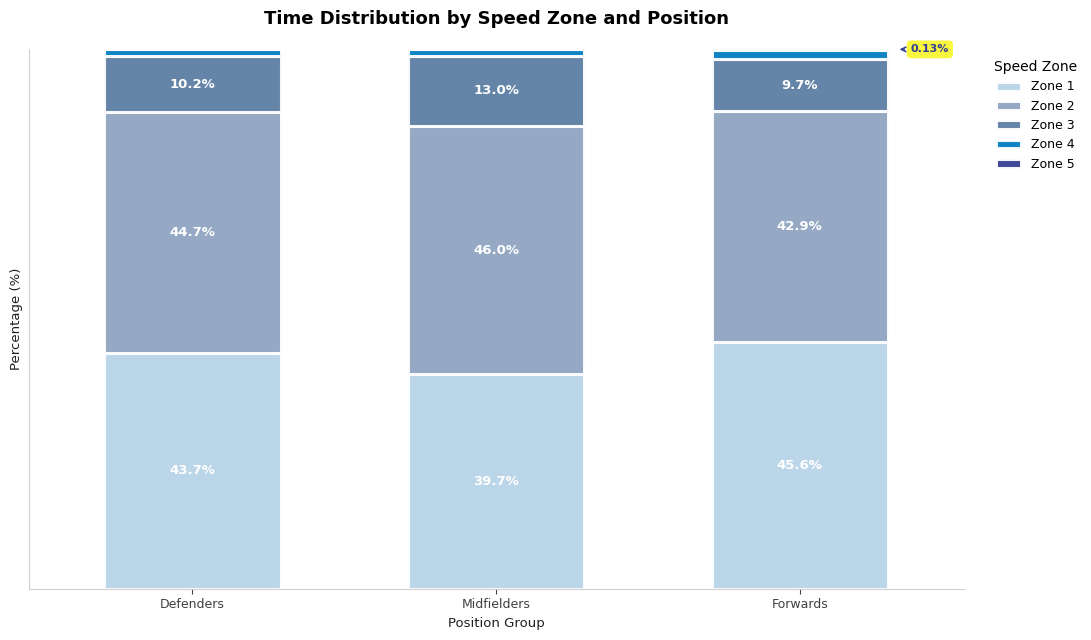

In [71]:
from matplotlib.patches import Patch

# Stacked bar chart: percentage time in each speed zone by position (creative styling)
speed_zone_cols = [
    'time_in_speed_zone_1_secs',
    'time_in_speed_zone_2_secs',
    'time_in_speed_zone_3_secs',
    'time_in_speed_zone_4_secs',
    'time_in_speed_zone_5_secs'
]

# Group by position and sum times
zone_by_position = df.groupby('general_position')[speed_zone_cols].sum()

# Reorder positions
position_order = ['Defenders', 'Midfielders', 'Forwards']
zone_by_position = zone_by_position.reindex(position_order)

# Prepare labels
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]
zone_by_position.columns = zone_labels

# Convert to percentages
zone_pct = zone_by_position.div(zone_by_position.sum(axis=1), axis=0) * 100

# Create professional FUFA color gradient
zone_colors_stack = ['#B8D4E8', '#8FA3C1', '#5B7DA3', light_blue, dark_blue]

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='white')
zone_pct.plot(
    kind='bar',
    stacked=True,
    color=zone_colors_stack,
    ax=ax,
    edgecolor='white',
    linewidth=2.2,
    width=0.58,
    alpha=0.94,
    legend=True
)

# Annotate values with professional styling
for i, pos in enumerate(zone_pct.index):
    cumulative = 0
    for j, zone in enumerate(zone_labels):
        value = zone_pct.loc[pos, zone]
        if value > 4:  # Annotate segments larger than 4%
            y = cumulative + value / 2
            ax.text(i, y, f'{value:.1f}%', ha='center', va='center', 
                   fontsize=9.5, color='white', fontweight='600')
        elif value > 0.1 and zone == 'Zone 5':  # Highlight Zone 5 smaller segments
            y = cumulative + value / 2
            ax.annotate(
                f'{value:.2f}%',
                xy=(i + 0.32, y),
                xytext=(10, 0),
                textcoords='offset points',
                ha='left', va='center',
                fontsize=8, fontweight='600',
                color=dark_blue,
                bbox=dict(boxstyle='round,pad=0.35', facecolor=yellow, 
                         edgecolor='none', alpha=0.75),
                arrowprops=dict(arrowstyle='->', color=dark_blue, lw=1.2)
            )
        cumulative += value

ax.set_xlabel('Position Group', fontsize=11, fontweight='400', color='#1F1F1F')
ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='400', color='#1F1F1F')
ax.set_title('Time Distribution by Speed Zone and Position', fontsize=13, fontweight='bold', pad=18)
ax.set_xticklabels(position_order, rotation=0, fontsize=10, fontweight='400')

apply_fufa_chart_theme(ax, remove_y_ticks=True, remove_y_labels=True)

# Format legend
ax.legend(title='Speed Zone', frameon=False, bbox_to_anchor=(1.02, 1), 
         loc='upper left', fontsize=9, title_fontsize=10)

# Y-axis from 0 to 100%
ax.set_ylim(0, 100)

# Tick styling
ax.tick_params(axis='x', labelsize=9, colors='#404040')
ax.tick_params(axis='y', labelsize=8, colors='#404040')

plt.tight_layout()
plt.show()

In [72]:
zone_by_position

,Zone 1,Zone 2,Zone 3,Zone 4,Zone 5
general_position,,,,,
Defenders,567932.2,581562.9,133008.7,17322.1,670.3
Midfielders,447968.9,518890.9,146491.5,14134.9,325.2
Forwards,426535.3,400623.8,90576.8,15926.3,1237.1


In [73]:
style_table_for_docs(zone_pct.round(2))

,Zone 1,Zone 2,Zone 3,Zone 4,Zone 5
general_position,,,,,
Defenders,43.670000,44.720000,10.230000,1.330000,0.050000
Midfielders,39.720000,46.010000,12.990000,1.250000,0.030000
Forwards,45.620000,42.850000,9.690000,1.700000,0.130000


C:\Users\Travail\AppData\Local\Temp\ipykernel_11968\2880846935.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.99])


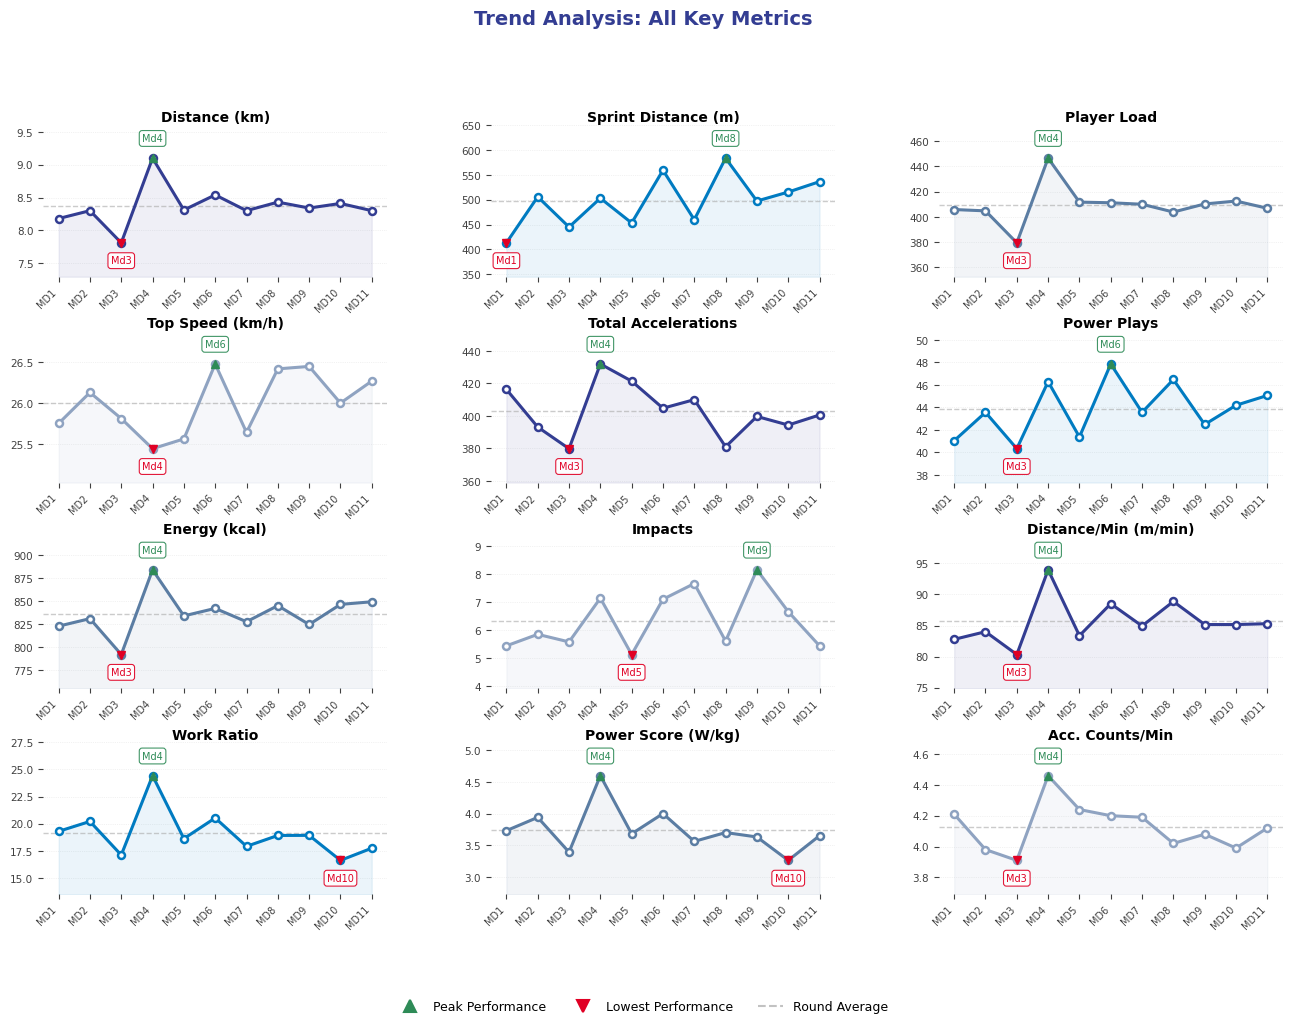

In [74]:
# Create compact multi-metric trend dashboard with improvements
fig = plt.figure(figsize=(16, 10), facecolor='white')
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

# Select key metrics (volume + intensity mix)
metrics_to_visualize = [
    ('distance_km', 'Distance (km)', dark_blue),
    ('sprint_distance_m', 'Sprint Distance (m)', light_blue),
    ('player_load', 'Player Load', '#5B7DA3'),
    ('top_speed_kmh', 'Top Speed (km/h)', '#8FA3C1'),
    ('total_accelerations', 'Total Accelerations', dark_blue),
    ('power_plays', 'Power Plays', light_blue),
    ('energy_kcal', 'Energy (kcal)', '#5B7DA3'),
    ('impacts', 'Impacts', '#8FA3C1'),
    ('distance_per_min_mmin', 'Distance/Min (m/min)', dark_blue),
    ('work_ratio', 'Work Ratio', light_blue),
    ('power_score_wkg', 'Power Score (W/kg)', '#5B7DA3'),
    ('acc_counts_per_min', 'Acc. Counts/Min', '#8FA3C1'),
]

for idx, (metric, label, color) in enumerate(metrics_to_visualize):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    
    # Get data sorted by matchday
    data = avg_volume_per_matchday[['match_day', metric]].copy()
    data = data.dropna()
    
    # Set y-axis limits to exclude 0 and reduce thickness
    min_val = data[metric].min()
    max_val = data[metric].max()
    y_range = max_val - min_val
    y_min = max(0, min_val - 0.40 * y_range)  # Add 5% padding below minimum
    y_max = max_val + 0.4 * y_range  # Add 10% padding above maximum
    ax.set_ylim(y_min, y_max)
    
    # Plot line with markers
    ax.plot(range(len(data)), data[metric].values, 
           marker='o', color=color, linewidth=2.2, markersize=5,
           markerfacecolor='white', markeredgecolor=color, markeredgewidth=1.8, zorder=2)
    
    # Add subtle fill under curve (reduced opacity)
    ax.fill_between(range(len(data)), y_min, data[metric].values, alpha=0.08, color=color)
    
    # average line
    avg_val = data[metric].mean()
    ax.axhline(avg_val, color='#A9A9A9', linestyle='--', linewidth=1, alpha=0.6, zorder=1)
    
    # Apply FUFA theme
    apply_fufa_chart_theme(ax, remove_y_labels=False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # Compact styling
    ax.set_title(label, fontsize=10, fontweight='600', color=black, pad=2)
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels([f'MD{i+1}' for i in range(len(data))], fontsize=7, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=7.5)
    ax.grid(axis='y', linestyle=':', alpha=0.2, linewidth=0.5)
    
    # Find min/max with their indices
    min_idx_pos = data[metric].idxmin()
    max_idx_pos = data[metric].idxmax()
    min_val_data = data.loc[min_idx_pos, metric]
    max_val_data = data.loc[max_idx_pos, metric]
    
    min_x_pos = list(data.index).index(min_idx_pos)
    max_x_pos = list(data.index).index(max_idx_pos)
    
    # Add min/max markers with MD labels
    ax.plot(min_x_pos, min_val_data, 'v', color=red, markersize=6, zorder=3)
    ax.plot(max_x_pos, max_val_data, '^', color='#2E8B57', markersize=6, zorder=3)
    
    # Annotate min/max with match day labels
    min_md = data.iloc[min_x_pos]['match_day']
    max_md = data.iloc[max_x_pos]['match_day']
    
    ax.annotate(f'{min_md}', xy=(min_x_pos, min_val_data), xytext=(0, -15),
               textcoords='offset points', ha='center', fontsize=7, fontweight='500',
               color=red, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                   edgecolor=red, linewidth=0.8, alpha=0.9))
    
    ax.annotate(f'{max_md}', xy=(max_x_pos, max_val_data), xytext=(0, 12),
               textcoords='offset points', ha='center', fontsize=7, fontweight='500',
               color='#2E8B57', bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                                        edgecolor='#2E8B57', linewidth=0.8, alpha=0.9))

fig.suptitle('Trend Analysis: All Key Metrics', 
            fontsize=14, fontweight='bold', y=0.995, color=dark_blue)

# Add legend in a dedicated area at the bottom
legend_elements = [
    plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='#2E8B57', 
              markersize=8, label='Peak Performance', markeredgecolor='#2E8B57', markeredgewidth=1.5),
    plt.Line2D([0], [0], marker='v', color='w', markerfacecolor=red, 
              markersize=8, label='Lowest Performance', markeredgecolor=red, markeredgewidth=1.5),
    plt.Line2D([0], [0], color='#A9A9A9', linestyle='--', linewidth=1.5, 
              label='Round Average', alpha=0.7)
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
          fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

In [75]:
# # Normalize all metrics for heatmap (0-1 scale) for trend visibility
# heatmap_data = avg_volume_per_matchday.set_index('match_day')[
#     [m for m, _, _ in metrics_to_visualize]
# ].copy()

# # Rename columns for readability
# heatmap_data.columns = [label for _, label, _ in metrics_to_visualize]

# # Normalize each metric to 0-1 range
# heatmap_normalized = heatmap_data.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)

# # Create heatmap
# fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')

# sns.heatmap(
#     heatmap_normalized.T,
#     cmap='RdYlGn',
#     center=0.5,
#     vmin=0, vmax=1,
#     cbar_kws={'label': 'Relative Performance (Low → High)'},
#     linewidths=0.8,
#     linecolor='white',
#     ax=ax,
#     annot=True,
#     fmt='.2f',
#     annot_kws={'fontsize': 8, 'fontweight': 'bold'},
#     cbar=True
# )

# ax.set_title('Season Trend Heatmap: All Metrics Normalized', 
#             fontsize=13, fontweight='bold', pad=15, color=dark_blue)
# ax.set_xlabel('Match Day', fontsize=11, fontweight='600')
# ax.set_ylabel('Metric', fontsize=11, fontweight='600')

# # Format x-axis as MD1, MD2, etc.
# xticklabels = [f"MD{i+1}" if i % 2 == 0 else "" for i in range(len(heatmap_data))]
# ax.set_xticklabels(xticklabels, rotation=0, fontsize=9)

# plt.tight_layout()
# plt.show()